# CIFAR, nanoGPT, GPT-2 and the profile figures

The large-model figures: CIFAR-10/ResNet18 (curves, cost, the optimisation-vs-
generalisation gap, the Sven landscape, the rank actually used), Fig. 5's parameter
fraction at scale, nanoGPT, GPT-2-small, and the six figures of the `profile_results_v3`
study.

## How this works

```python
f = pf.make('<figure>')          # draws it, writes NOTHING
f.show(zoom=2)                   # magnified screen copy (the PDF keeps its page size)
f.ax(0).set_ylabel('...')        # edit the matplotlib objects however you like
f.fig.set_size_inches(5.5, 2.4)  # f.axes = the builder's layout, f.flat = every panel
f.save()                         # writes iclr_manuscript/figures_iclr/<group>/<figure>.pdf,
                                 # the PNG twin and the provenance sidecar -- exactly as
                                 # `python -m paper_assets` does
```

Two kinds of option:

* **the figure's own knobs** — what it draws (methods, scans, panels), its geometry
  (`fraction`, `aspect`), line weights, legend placement. `pf.info('<figure>')` lists them
  with their defaults.
* **the generic cosmetics**, on every figure: `figsize`, `xlabel`, `ylabel`, `title`,
  `xlim`, `ylim`, `xscale`, `yscale`, `legend`, `suptitle`, `grid`, `tick_labelsize`,
  `rc`. Each takes a value for all panels, a list by panel position, or a dict keyed by
  panel index — e.g. `ylabel={0: 'Validation loss'}`, `legend={'loc': 'lower left',
  'ncol': 6, 'fontsize': 5}`.

Pass either to `pf.make(...)` for a one-off, or **pin** it so the paper build draws it
that way too:

```python
pf.pin('headline_curves', methods='all', aspect=0.95)   # -> paper_assets/figure_overrides.yaml
pf.rebuild('headline_curves')                           # draw with the pinned options + save
pf.unpin('headline_curves')                             # back to the builder's default
```

Pinned options live in `analysis/paper_assets/figure_overrides.yaml`, which
`python -m paper_assets` reads, so a full rebuild reproduces your version instead of
reverting it. Nothing in this notebook writes until you call `save()` or `rebuild()`, so
re-running it top to bottom is safe.

**A note on size.** These are drawn at their true size on the page (a 0.32-linewidth
panel is 1.76 in wide, 7 pt type), so they look small inline; `show(zoom=...)` only
magnifies the screen copy. To judge the type size, look at the PNG twin under
`agent_lab/paper_assets/<group>/` after saving — it is written at the physical size.

In [1]:
%matplotlib inline
import os
import sys

# This notebook lives in analysis/notebooks/paper/, but every analysis path is
# relative to analysis/ (plots_v2/, tables/, ../experiment_results), so run from there
# with the helper modules in analysis/lib/ on the path.
_A = os.getcwd()
while not all(os.path.isdir(os.path.join(_A, d)) for d in ('lib', 'notebooks')):
    _A, _prev = os.path.dirname(_A), _A
    if _A == _prev:
        raise RuntimeError('analysis/ not found above ' + os.getcwd())
os.chdir(_A)
sys.path.insert(0, _A)
sys.path.insert(0, os.path.join(_A, 'lib'))

import paper_assets.notebook as pf

pf.figures('large')

,figure,group,module,knobs,pinned,what
0,cifar_cost,large,large,"aspect, fraction, legend_fontsize, legend_loc,...",-,F7: seconds per epoch and peak GPU memory from...
1,cifar_curves_epoch,large,large,"aspect, band, extra_h, fraction, legend_band, ...",-,"F7a: CIFAR-10/ResNet18, validation loss and te..."
2,cifar_curves_time,large,large,"aspect, band, extra_h, fraction, legend_band, ...",-,F7b: the same curves vs standalone TRAINING TI...
3,cifar_gap,large,large,"aspect, diagonal, extra_h, fraction, legend_ba...",-,"F7: the train-vs-validation gap per method, on..."
4,cifar_landscape,large,large,"aspect, cbar_label, fraction, scans, style_fra...",-,"F7: Sven's (lr, rtol) landscape per k and per ..."
5,cifar_rank_used,large,large,"alpha, aspect, fraction, k_color, legend_fonts...",-,F7: the rank Sven actually inverted per epoch ...
6,fig5_cost,large,large,"aspect, extra_h, fraction, legend_fontsize, le...",-,F7d: peak memory and time per step against the...
7,fig5_quality,large,large,"aspect, chance_line, extra_h, fraction, legend...",-,F7c: loss and accuracy against the ACTUAL para...
8,gpt2,large,large,"aspect, cmap, cmap_lo, cmap_span, extra_h, fra...",-,"F11: GPT-2 small, validation loss vs optimisat..."
9,gpt2_lr,large,large,"aspect, extra_h, fraction, legend_fontsize, le...",-,F11: GPT-2 final loss against the learning rat...


## `cifar_cost`

F7: seconds per epoch and peak GPU memory from the standalone timing pass, one row per objective.

Its own knobs:

* `aspect` — default `0.95`
* `fraction` — default `0.49`
* `legend_fontsize` — default `None`
* `legend_loc` — default `'outside lower center'`
* `legend_ncol` — default `3`
* `log` — default `True`
* `scans` — default `None`
* `style_fraction` — default `None`
* `title_fontsize` — default `None`
* `xtick_fontsize` — default `5.6`


Loaded 600 runs from ../experiment_results/_cache/cifar10_resnet_scan_labelRegression.slim.pkl (slim cache)
Loaded 55 runs from ../experiment_results/_cache/cifar10_resnet_scan_labelRegression_timing.slim.pkl (slim cache)


Loaded 785 runs from ../experiment_results/_cache/cifar10_resnet_ce_scan.slim.pkl (slim cache)
Loaded 60 runs from ../experiment_results/_cache/cifar10_resnet_ce_scan_timing.slim.pkl (slim cache)


Loaded 140 runs from ../experiment_results/_cache/exp_nanogpt_speedrun.slim.pkl (slim cache)
Loaded 25 runs from ../experiment_results/_cache/exp_nanogpt_speedrun_timing.slim.pkl (slim cache)


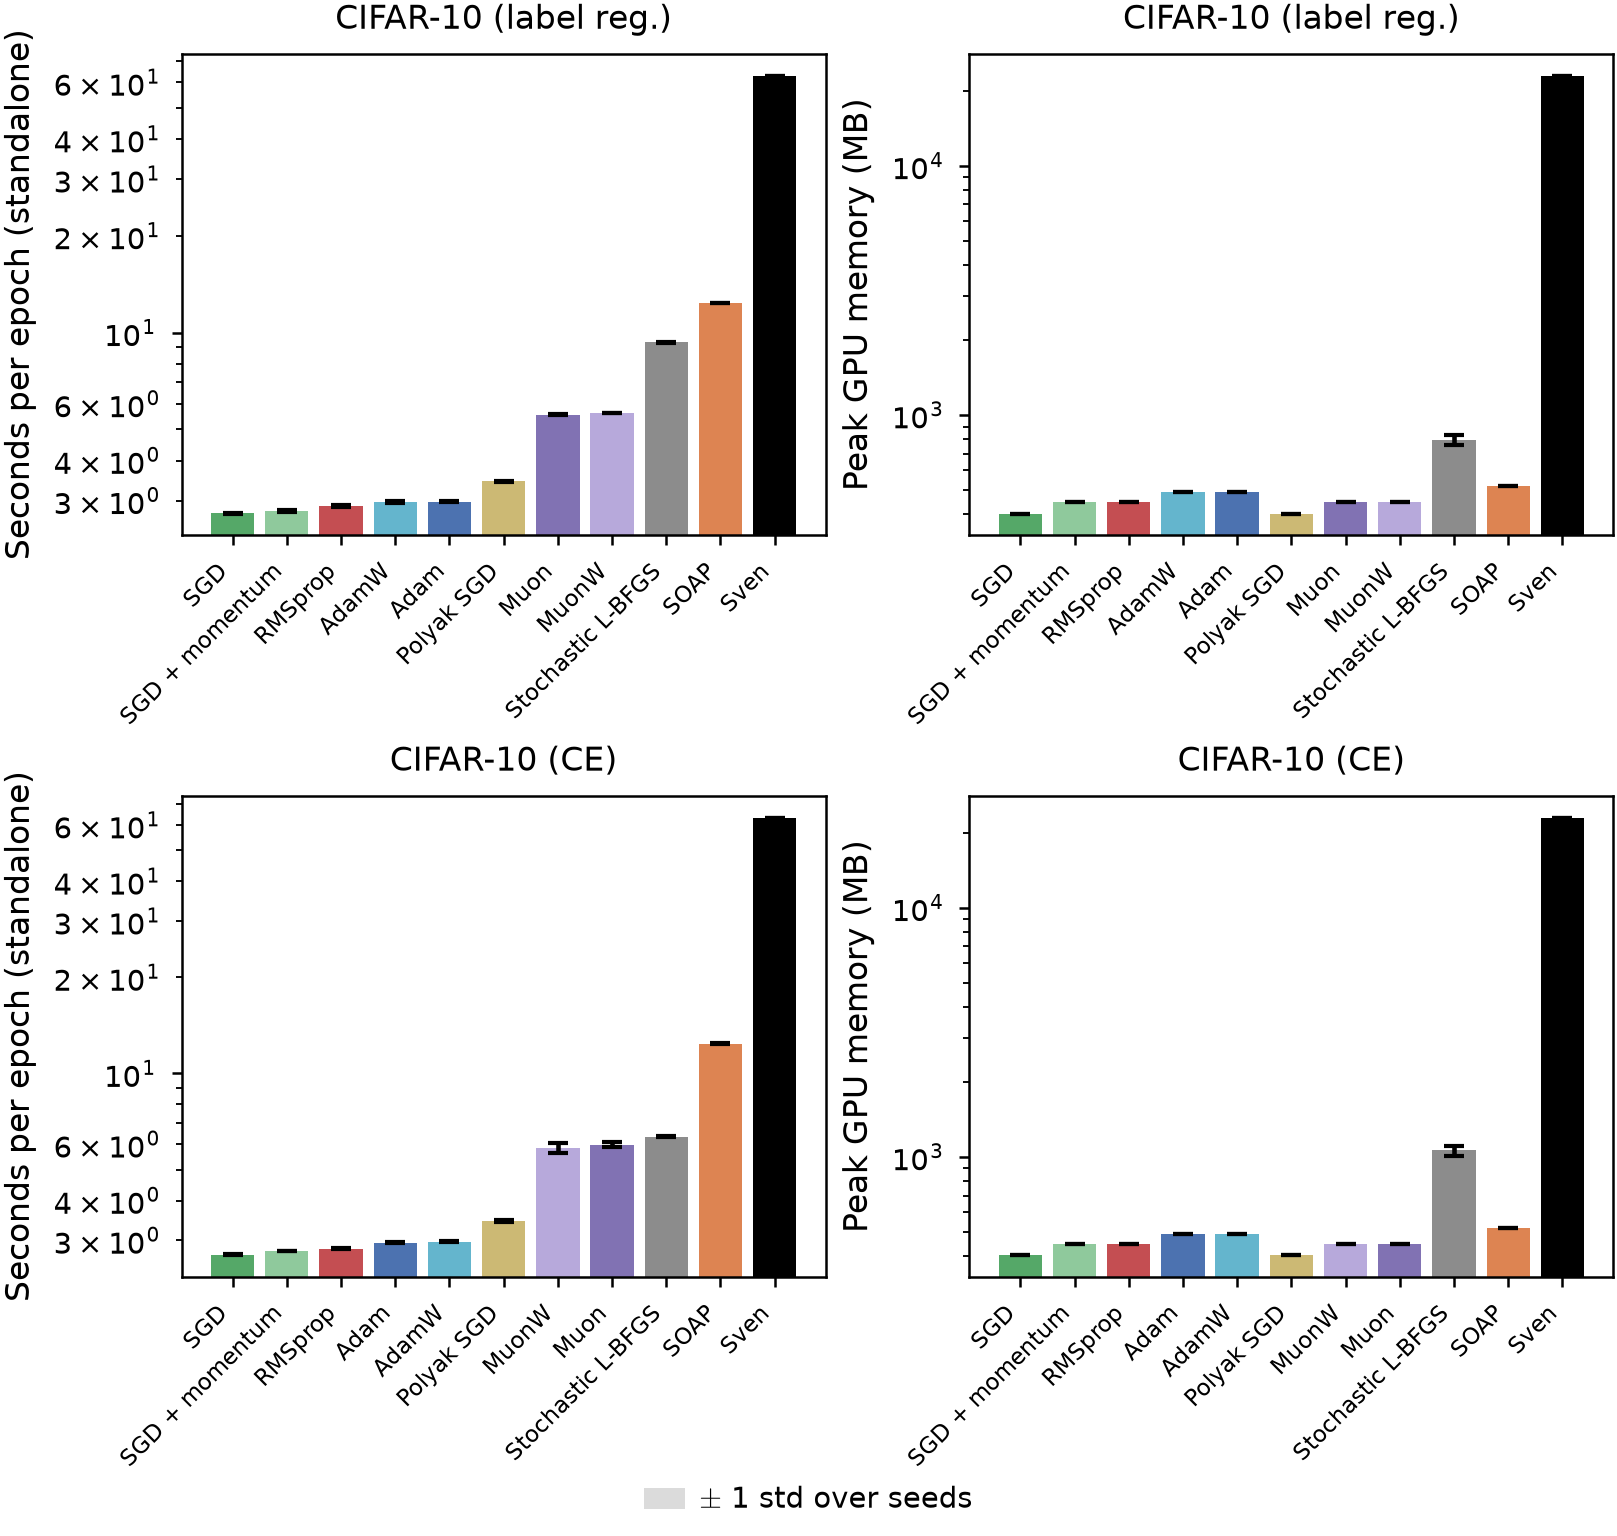

cifar_cost: 5.39 x 5.12 in on the page (shown at 2x)


In [2]:
f = pf.make('cifar_cost')
f.show(zoom=2)

In [3]:
# --- edit cifar_cost -------------------------------------------------------
# its own knobs: aspect, fraction, legend_fontsize, legend_loc, legend_ncol, log, scans, style_fraction, title_fontsize, xtick_fontsize
# f = pf.make('cifar_cost', aspect=0.95, fraction=0.49, legend_fontsize=None)
# f = pf.make('cifar_cost', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('cifar_cost', aspect=0.95)              # ... and make the CLI agree

## `cifar_curves_epoch`

F7a: CIFAR-10/ResNet18, validation loss and test accuracy vs EPOCH (confirmation seeds), one row per objective.

Its own knobs:

* `aspect` — default `0.85`
* `band` — default `True`
* `extra_h` — default `0.62`
* `fraction` — default `0.49`
* `legend_band` — default `True`
* `legend_fontsize` — default `None`
* `legend_loc` — default `'outside lower center'`
* `legend_ncol` — default `4`
* `lw` — default `0.85`
* `lw_sven` — default `1.4`
* `lw_time` — default `0.85`
* `methods` — default `None`
* `note_xy_acc` — default `[0.02, 0.03]`
* `note_xy_loss` — default `[0.35, 0.03]`
* `panels` — default `None`
* `scans` — default `None`
* `seed_note` — default `True`
* `style_fraction` — default `None`
* `title_fontsize` — default `None`
* `versus` — default `'epoch'`


Loaded 55 runs from ../experiment_results/_cache/cifar10_resnet_scan_labelRegression_confirm.slim.pkl (slim cache)
Loaded 60 runs from ../experiment_results/_cache/cifar10_resnet_ce_scan_confirm.slim.pkl (slim cache)
Loaded 25 runs from ../experiment_results/_cache/exp_nanogpt_speedrun_confirm.slim.pkl (slim cache)


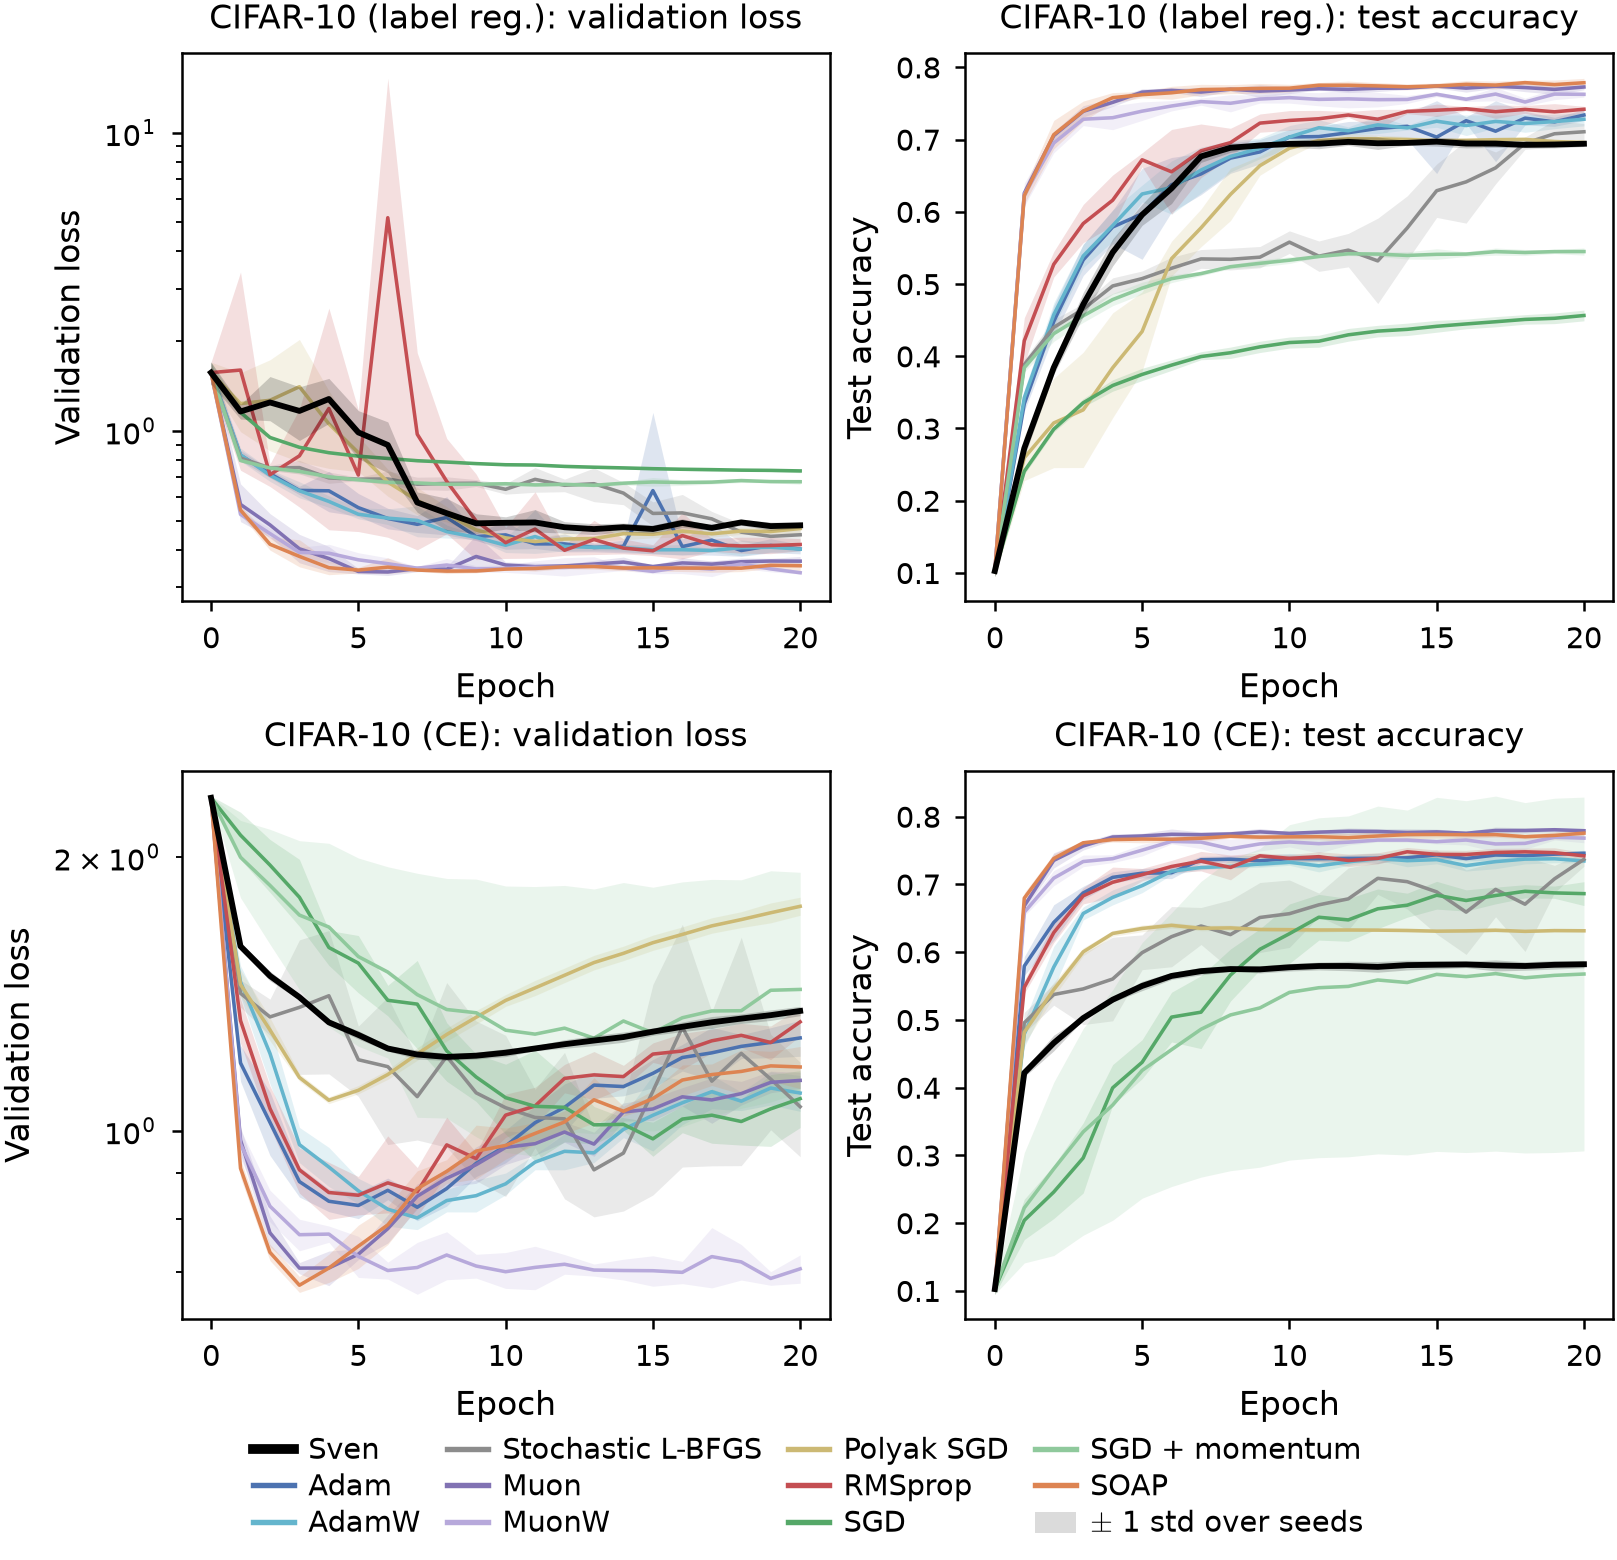

cifar_curves_epoch: 5.39 x 5.20 in on the page (shown at 2x)


In [4]:
f = pf.make('cifar_curves_epoch')
f.show(zoom=2)

In [5]:
# --- edit cifar_curves_epoch -------------------------------------------------------
# its own knobs: aspect, band, extra_h, fraction, legend_band, legend_fontsize, legend_loc, legend_ncol, lw, lw_sven, lw_time, methods, note_xy_acc, note_xy_loss, panels, scans, seed_note, style_fraction, title_fontsize, versus
# f = pf.make('cifar_curves_epoch', aspect=0.85, band=True, extra_h=0.62)
# f = pf.make('cifar_curves_epoch', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('cifar_curves_epoch', aspect=0.95)              # ... and make the CLI agree

## `cifar_curves_time`

F7b: the same curves vs standalone TRAINING TIME (the {scan}_timing pass), on a log time axis with the untrained point dropped.

Its own knobs:

* `aspect` — default `0.85`
* `band` — default `True`
* `extra_h` — default `0.62`
* `fraction` — default `0.49`
* `legend_band` — default `True`
* `legend_fontsize` — default `None`
* `legend_loc` — default `'outside lower center'`
* `legend_ncol` — default `4`
* `lw` — default `0.85`
* `lw_sven` — default `1.4`
* `lw_time` — default `0.85`
* `methods` — default `None`
* `note_xy_acc` — default `[0.02, 0.03]`
* `note_xy_loss` — default `[0.35, 0.03]`
* `panels` — default `None`
* `scans` — default `None`
* `seed_note` — default `True`
* `style_fraction` — default `None`
* `title_fontsize` — default `None`
* `versus` — default `'time'`


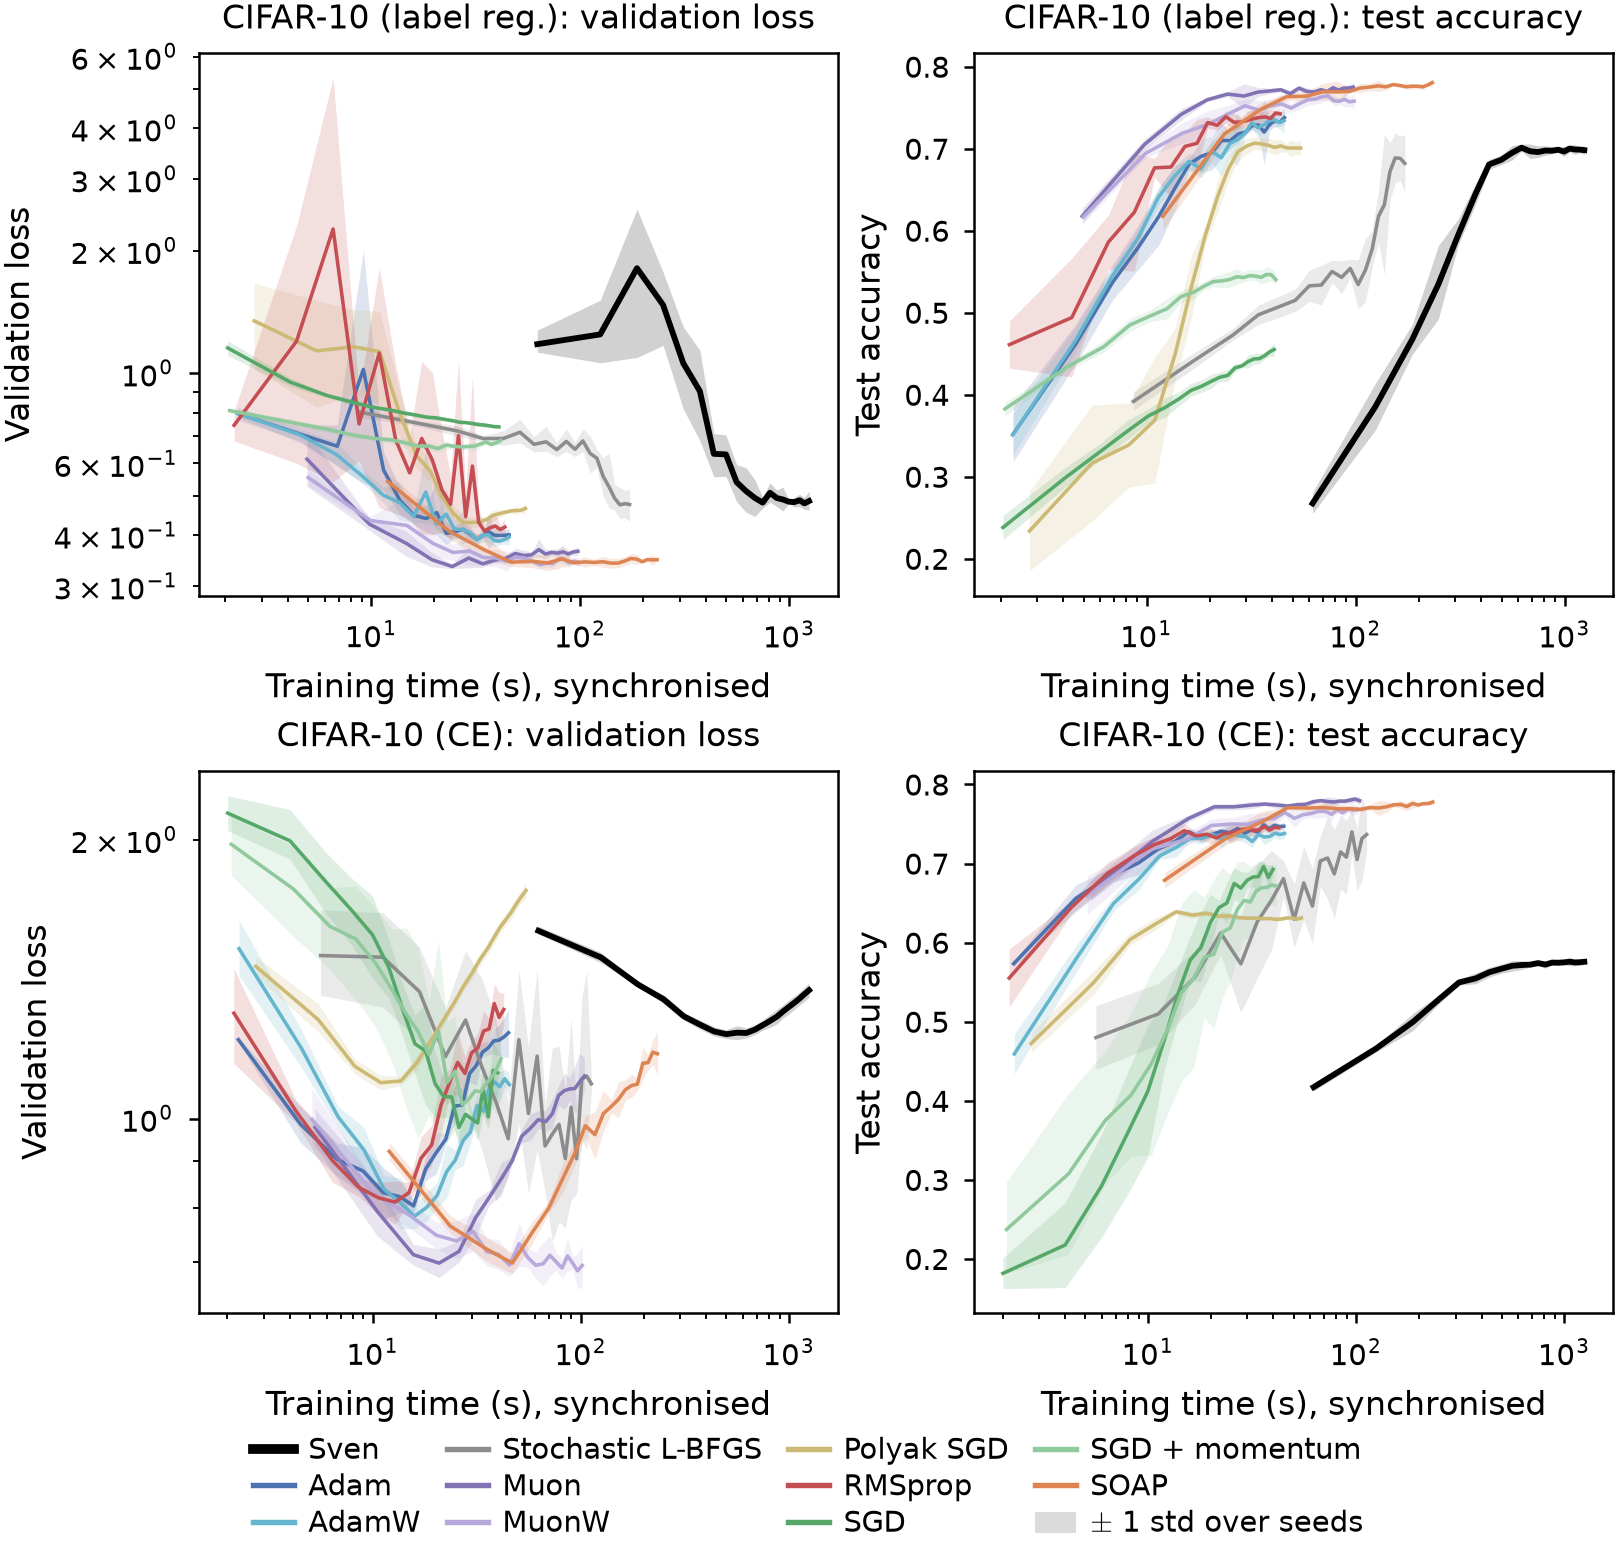

cifar_curves_time: 5.39 x 5.20 in on the page (shown at 2x)


In [6]:
f = pf.make('cifar_curves_time')
f.show(zoom=2)

In [7]:
# --- edit cifar_curves_time -------------------------------------------------------
# its own knobs: aspect, band, extra_h, fraction, legend_band, legend_fontsize, legend_loc, legend_ncol, lw, lw_sven, lw_time, methods, note_xy_acc, note_xy_loss, panels, scans, seed_note, style_fraction, title_fontsize, versus
# f = pf.make('cifar_curves_time', aspect=0.85, band=True, extra_h=0.62)
# f = pf.make('cifar_curves_time', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('cifar_curves_time', aspect=0.95)              # ... and make the CLI agree

## `cifar_gap`

F7: the train-vs-validation gap per method, one panel per objective (``diagonal`` draws the no-gap line, ``marker_size`` is the scatter size).

Its own knobs:

* `aspect` — default `0.92`
* `diagonal` — default `True`
* `extra_h` — default `0.6`
* `fraction` — default `0.49`
* `legend_band` — default `False`
* `legend_fontsize` — default `None`
* `legend_loc` — default `'outside lower center'`
* `legend_ncol` — default `4`
* `marker_size` — default `16`
* `pad_hi` — default `1.35`
* `pad_lo` — default `0.75`
* `scans` — default `None`
* `style_fraction` — default `None`
* `title_fontsize` — default `None`


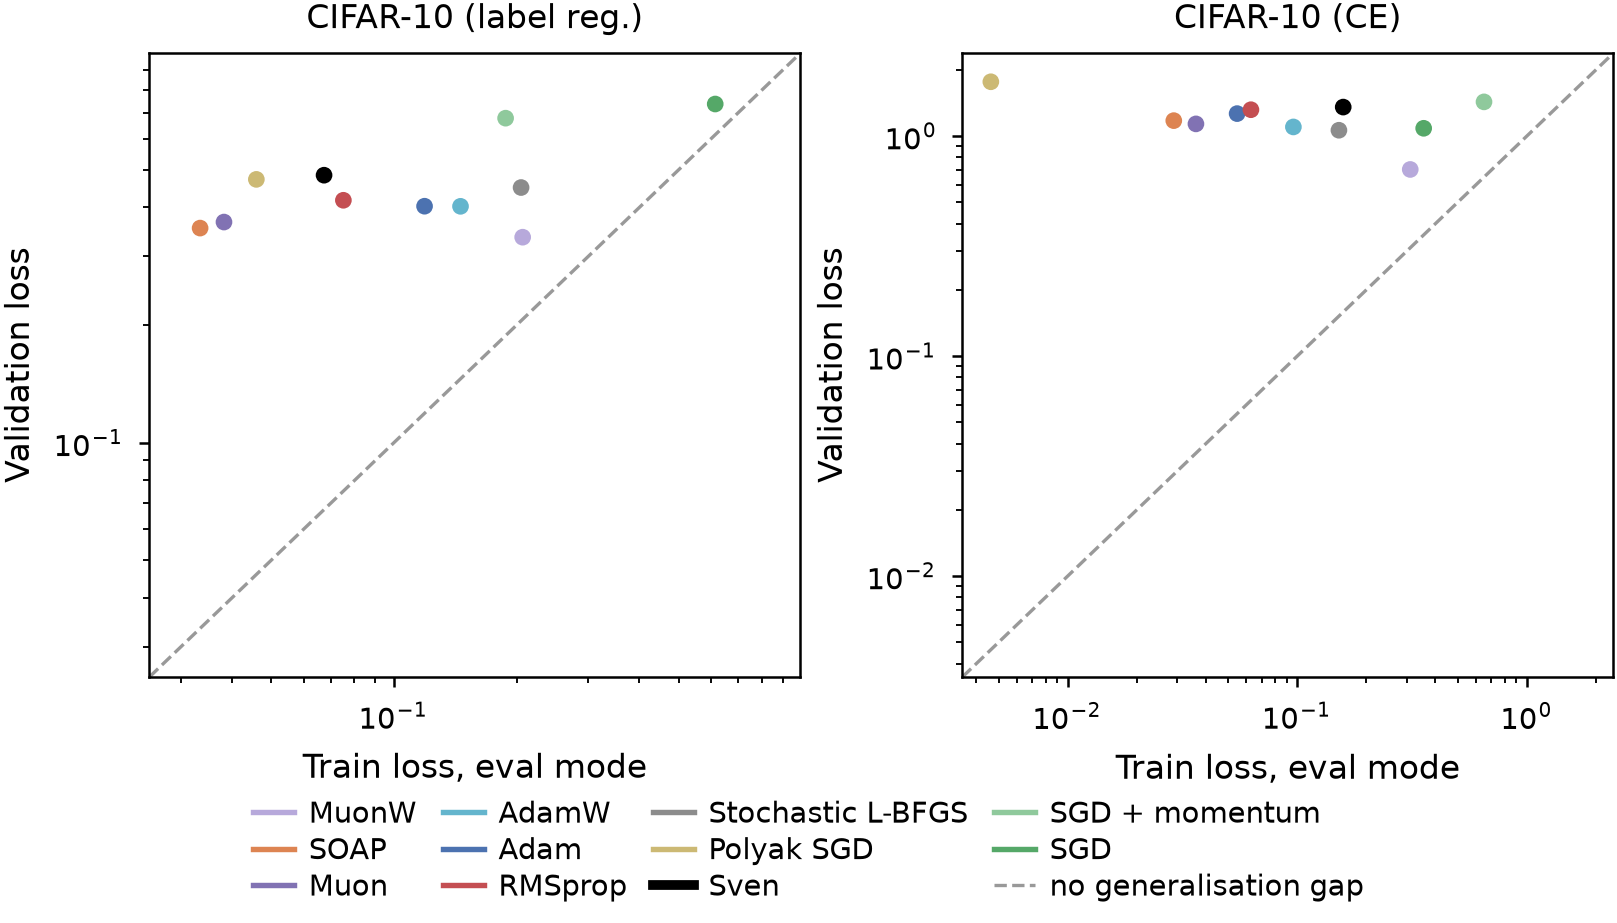

cifar_gap: 5.39 x 3.08 in on the page (shown at 2x)


In [8]:
f = pf.make('cifar_gap')
f.show(zoom=2)

In [9]:
# --- edit cifar_gap -------------------------------------------------------
# its own knobs: aspect, diagonal, extra_h, fraction, legend_band, legend_fontsize, legend_loc, legend_ncol, marker_size, pad_hi, pad_lo, scans, style_fraction, title_fontsize
# f = pf.make('cifar_gap', aspect=0.92, diagonal=True, extra_h=0.6)
# f = pf.make('cifar_gap', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('cifar_gap', aspect=0.95)              # ... and make the CLI agree

## `cifar_landscape`

F7: Sven's (lr, rtol) landscape per k and per objective, one colour scale per objective.

Its own knobs:

* `aspect` — default `0.95`
* `cbar_label` — default `'$\\log_{10}$ val loss'`
* `fraction` — default `0.49`
* `scans` — default `None`
* `style_fraction` — default `None`
* `title_fontsize` — default `None`


Loaded 600 runs from ../experiment_results/_cache/cifar10_resnet_scan_labelRegression.slim.pkl (slim cache)


cifar10_resnet_scan_labelRegression: 600 runs  |  B=128, 20 epochs, 5 seeds  |  Sven k=[64, 128] rtol=[0.0001, 0.001, 0.01]
  33 diverged run(s), excluded from seed means: {'SGDm': 15, 'SGD': 13, 'SVD': 5}
  manifest: 600 of 600 intended runs present, 0 with no record
Loaded 785 runs from ../experiment_results/_cache/cifar10_resnet_ce_scan.slim.pkl (slim cache)


cifar10_resnet_ce_scan: 785 runs  |  B=128, 20 epochs, 5 seeds  |  Sven k=[64, 128] rtol=[0.0001, 0.001, 0.01, 0.03, 0.1, 0.3]
  11 diverged run(s), excluded from seed means: {'RMSprop': 8, 'SOAP': 1, 'Muon': 1, 'SGDm': 1}
  manifest: 785 of 635 intended runs present, 0 with no record
Loaded 140 runs from ../experiment_results/_cache/exp_nanogpt_speedrun.slim.pkl (slim cache)
exp_nanogpt_speedrun: 140 runs  |  B=64, 50 epochs, 5 seeds  |  Sven k=[64] rtol=[0.001]
  manifest: 140 of 140 intended runs present, 0 with no record


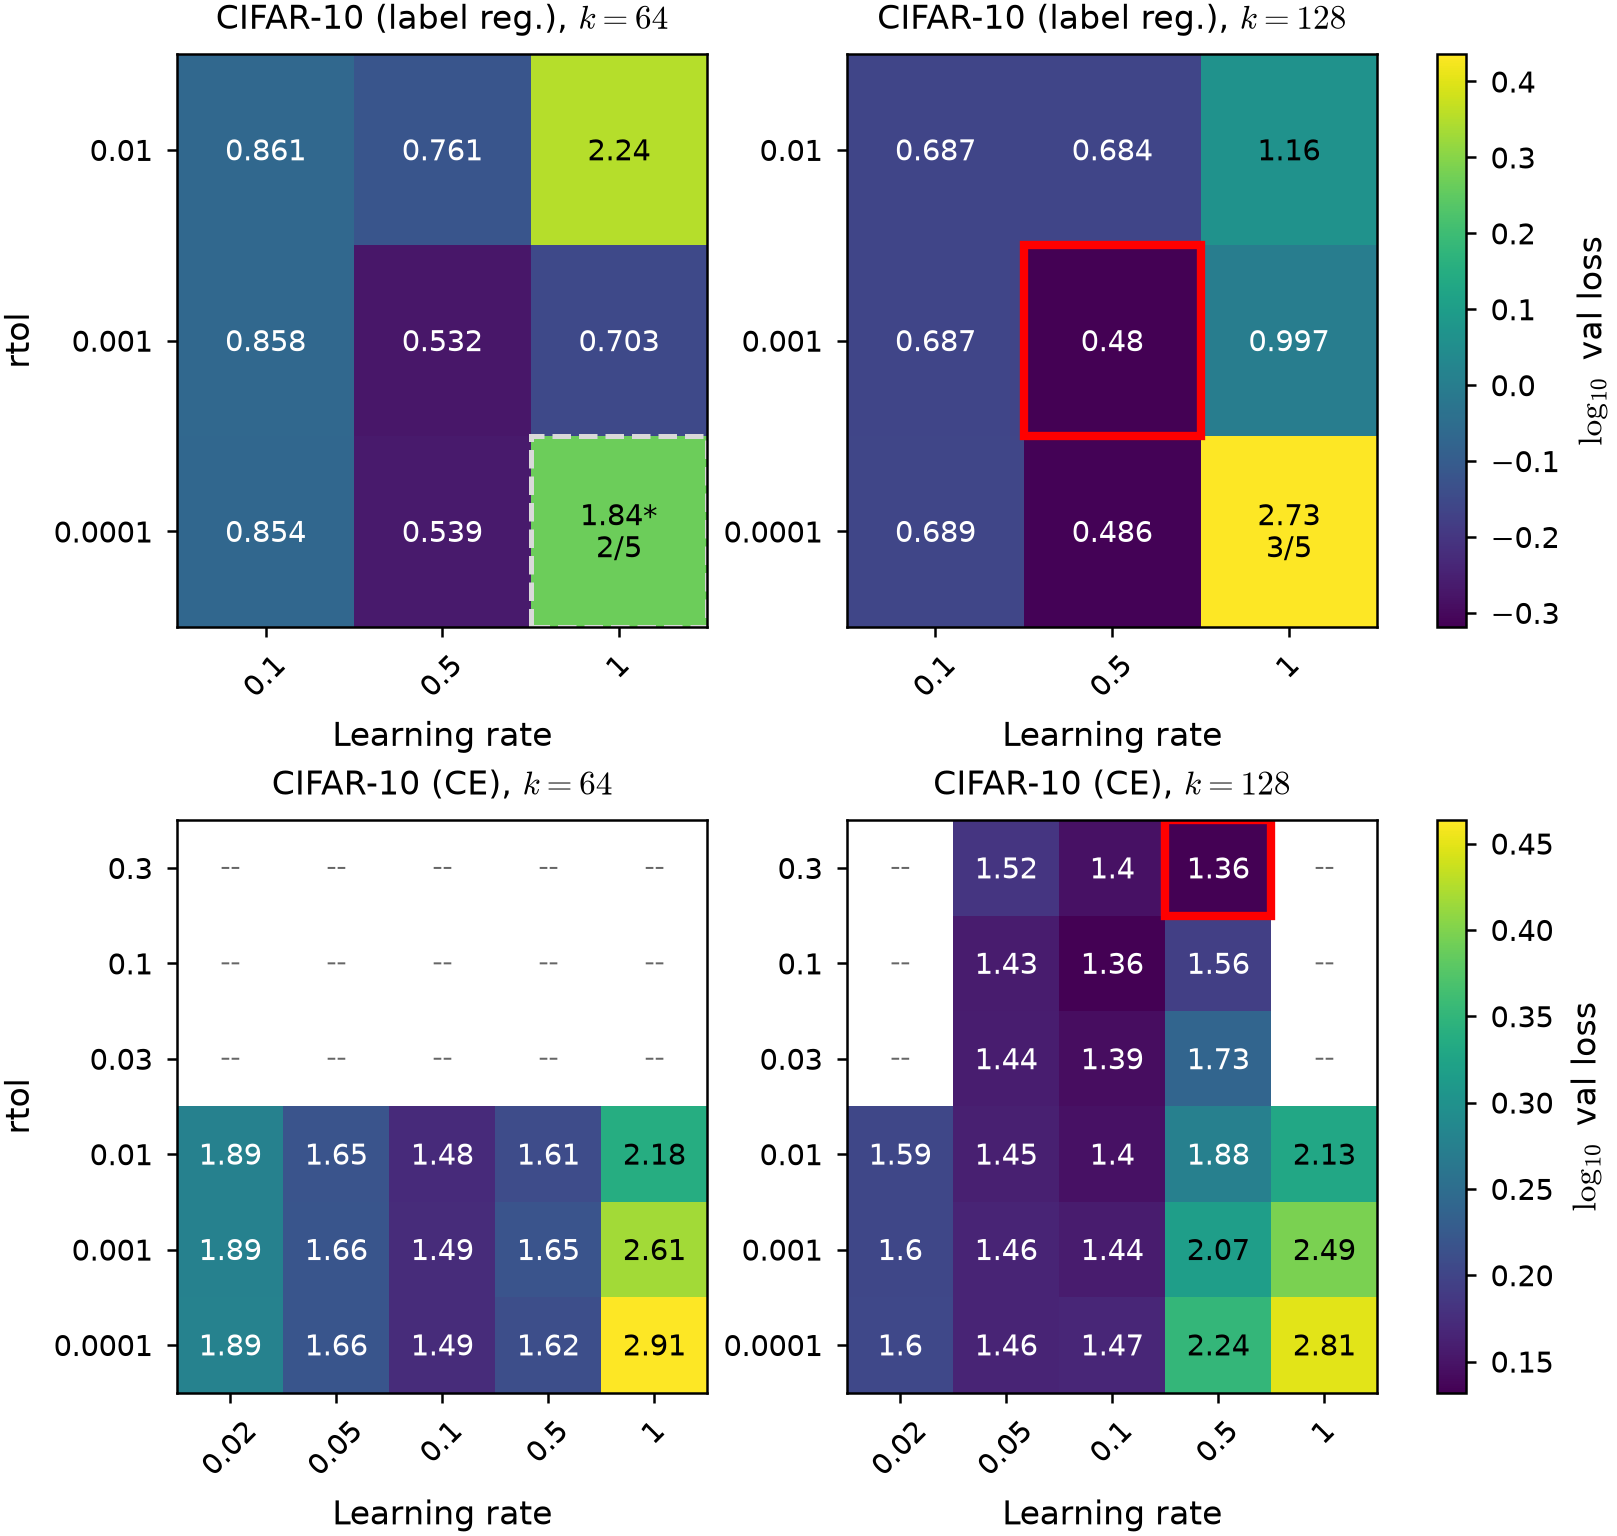

cifar_landscape: 5.39 x 5.12 in on the page (shown at 2x)


In [10]:
f = pf.make('cifar_landscape')
f.show(zoom=2)

In [11]:
# --- edit cifar_landscape -------------------------------------------------------
# its own knobs: aspect, cbar_label, fraction, scans, style_fraction, title_fontsize
# f = pf.make('cifar_landscape', aspect=0.95, cbar_label='$\\log_{10}$ val loss', fraction=0.49)
# f = pf.make('cifar_landscape', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('cifar_landscape', aspect=0.95)              # ... and make the CLI agree

## `cifar_rank_used`

F7: the rank Sven actually inverted per epoch (one line per seed) against its k cap.

Its own knobs:

* `alpha` — default `0.55`
* `aspect` — default `0.85`
* `fraction` — default `0.49`
* `k_color` — default `'C3'`
* `legend_fontsize` — default `5.8`
* `legend_loc` — default `'lower left'`
* `lw` — default `0.9`
* `scans` — default `None`
* `style_fraction` — default `None`
* `title_fontsize` — default `None`
* `ylim_pad` — default `1.08`


Loaded 55 runs from ../experiment_results/_cache/cifar10_resnet_scan_labelRegression_diag.slim.pkl (slim cache)
Loaded 60 runs from ../experiment_results/_cache/cifar10_resnet_ce_scan_diag.slim.pkl (slim cache)


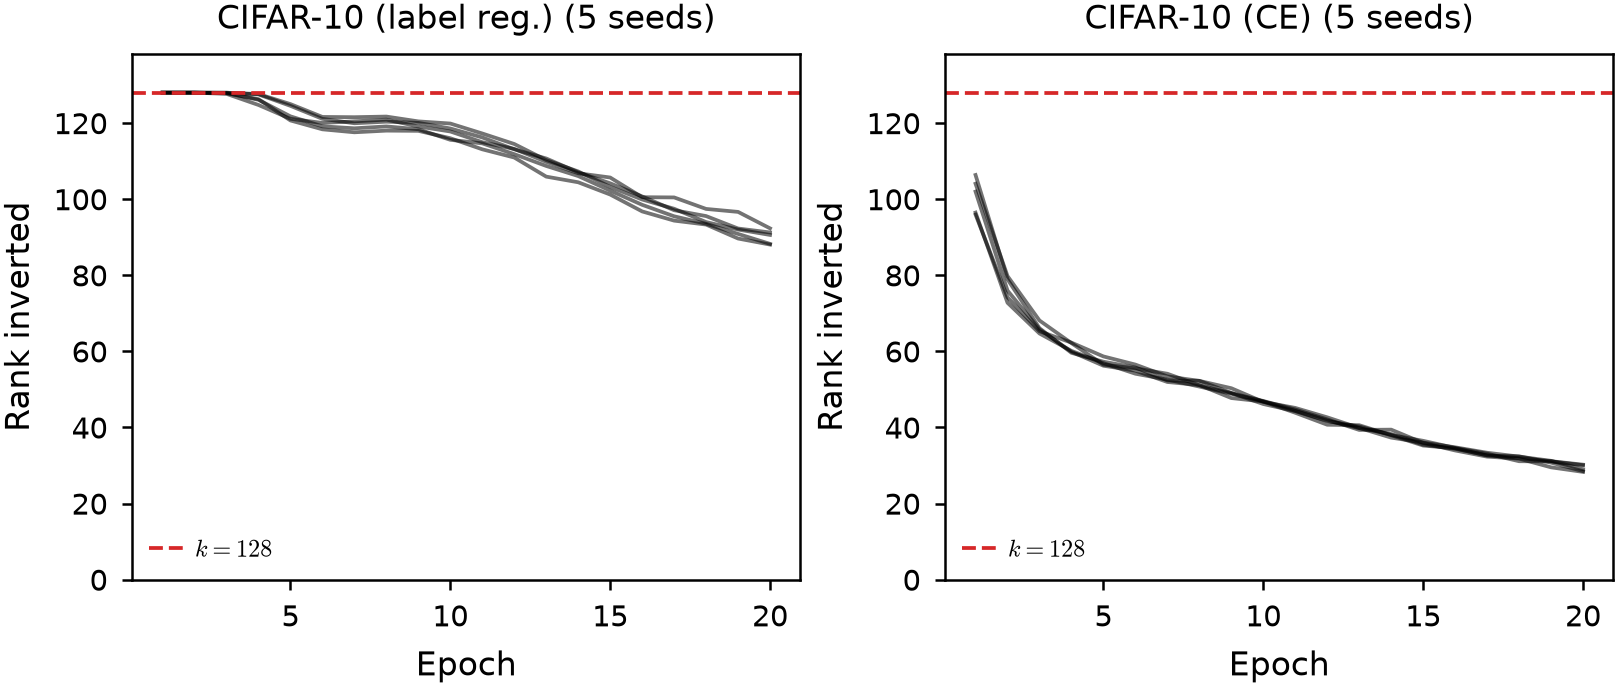

cifar_rank_used: 5.39 x 2.29 in on the page (shown at 2x)


In [12]:
f = pf.make('cifar_rank_used')
f.show(zoom=2)

In [13]:
# --- edit cifar_rank_used -------------------------------------------------------
# its own knobs: alpha, aspect, fraction, k_color, legend_fontsize, legend_loc, lw, scans, style_fraction, title_fontsize, ylim_pad
# f = pf.make('cifar_rank_used', alpha=0.55, aspect=0.85, fraction=0.49)
# f = pf.make('cifar_rank_used', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('cifar_rank_used', aspect=0.95)              # ... and make the CLI agree

## `fig5_cost`

F7d: peak memory and time per step against the actual parameter fraction; ``profile_overlay`` overlays the profile's own param_fraction study and ``profile_step_times`` (None = only when the root is v3) its step times.

Its own knobs:

* `aspect` — default `0.9`
* `extra_h` — default `0.42`
* `fraction` — default `0.49`
* `legend_fontsize` — default `None`
* `legend_loc` — default `'outside lower center'`
* `legend_ncol` — default `2`
* `profile_overlay` — default `True`
* `profile_step_times` — default `None`
* `style_fraction` — default `None`
* `styles` — default `[['-', 'o'], ['--', 's'], [':', '^'], ['-.', 'D']]`
* `title_fontsize` — default `None`


Loaded 30 runs from ../experiment_results/_cache/rebuttal_fig5_cifar_paramfrac_scan.slim.pkl (slim cache)


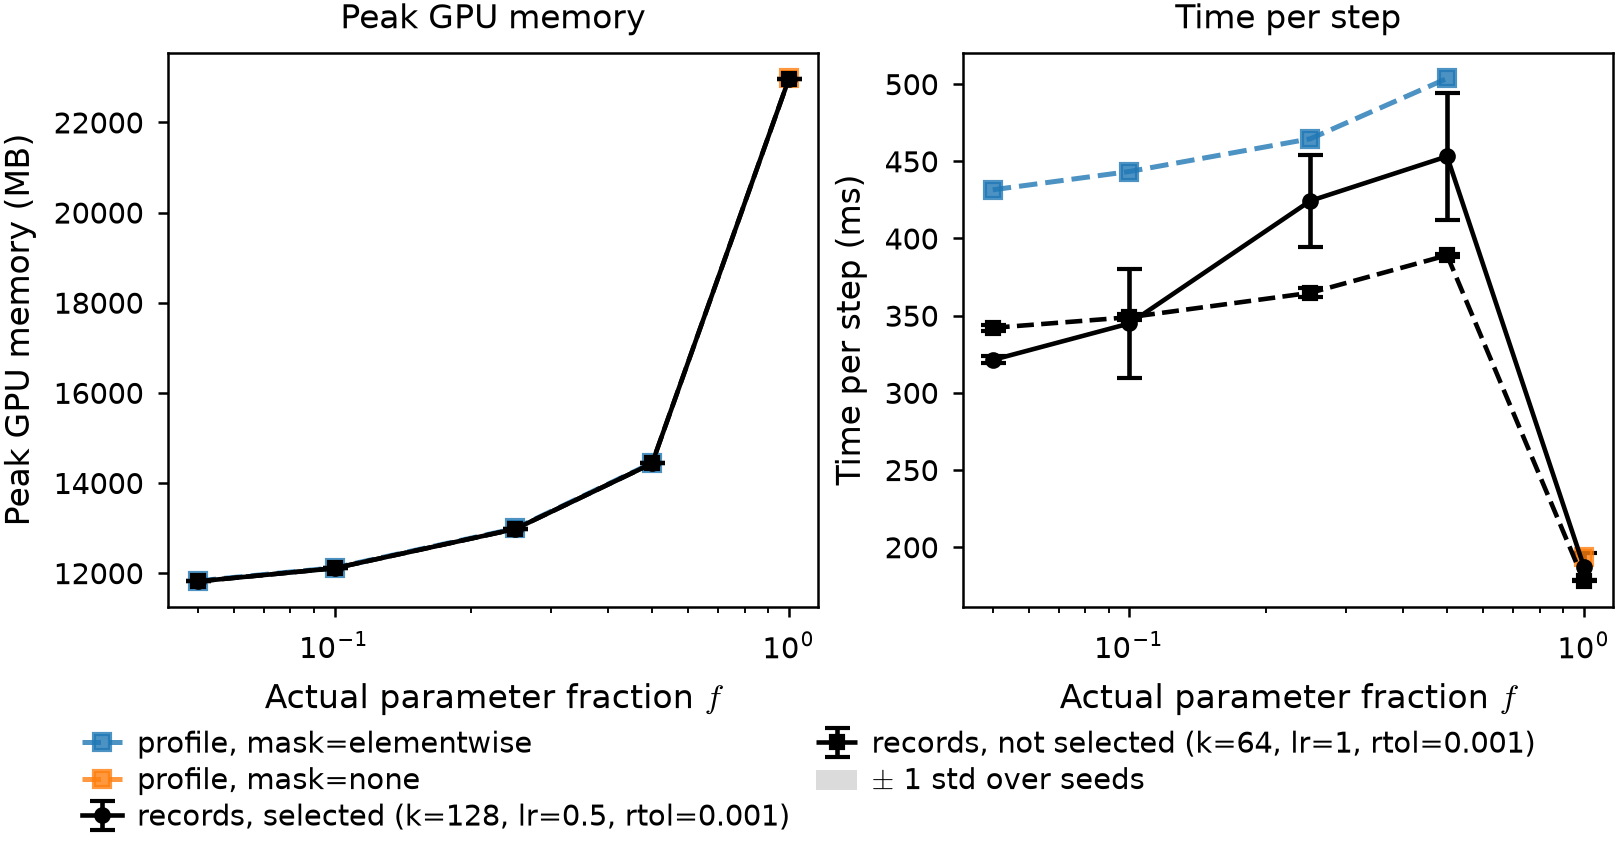

fig5_cost: 5.39 x 2.85 in on the page (shown at 2x)


In [14]:
f = pf.make('fig5_cost')
f.show(zoom=2)

In [15]:
# --- edit fig5_cost -------------------------------------------------------
# its own knobs: aspect, extra_h, fraction, legend_fontsize, legend_loc, legend_ncol, profile_overlay, profile_step_times, style_fraction, styles, title_fontsize
# f = pf.make('fig5_cost', aspect=0.9, extra_h=0.42, fraction=0.49)
# f = pf.make('fig5_cost', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('fig5_cost', aspect=0.95)              # ... and make the CLI agree

## `fig5_quality`

F7c: loss and accuracy against the ACTUAL parameter fraction, every Sven configuration on disk (``styles`` is one [linestyle, marker] per configuration, the selected one first).

Its own knobs:

* `aspect` — default `0.9`
* `chance_line` — default `True`
* `extra_h` — default `0.52`
* `fraction` — default `0.49`
* `legend_fontsize` — default `None`
* `legend_loc` — default `'outside lower center'`
* `legend_marker_size` — default `3.0`
* `legend_ncol` — default `3`
* `note_fontsize` — default `5.2`
* `seed_note` — default `True`
* `style_fraction` — default `None`
* `styles` — default `[['-', 'o'], ['--', 's'], [':', '^'], ['-.', 'D']]`
* `title_fontsize` — default `None`
* `xlim_pad_hi` — default `1.5`
* `xlim_pad_lo` — default `0.85`


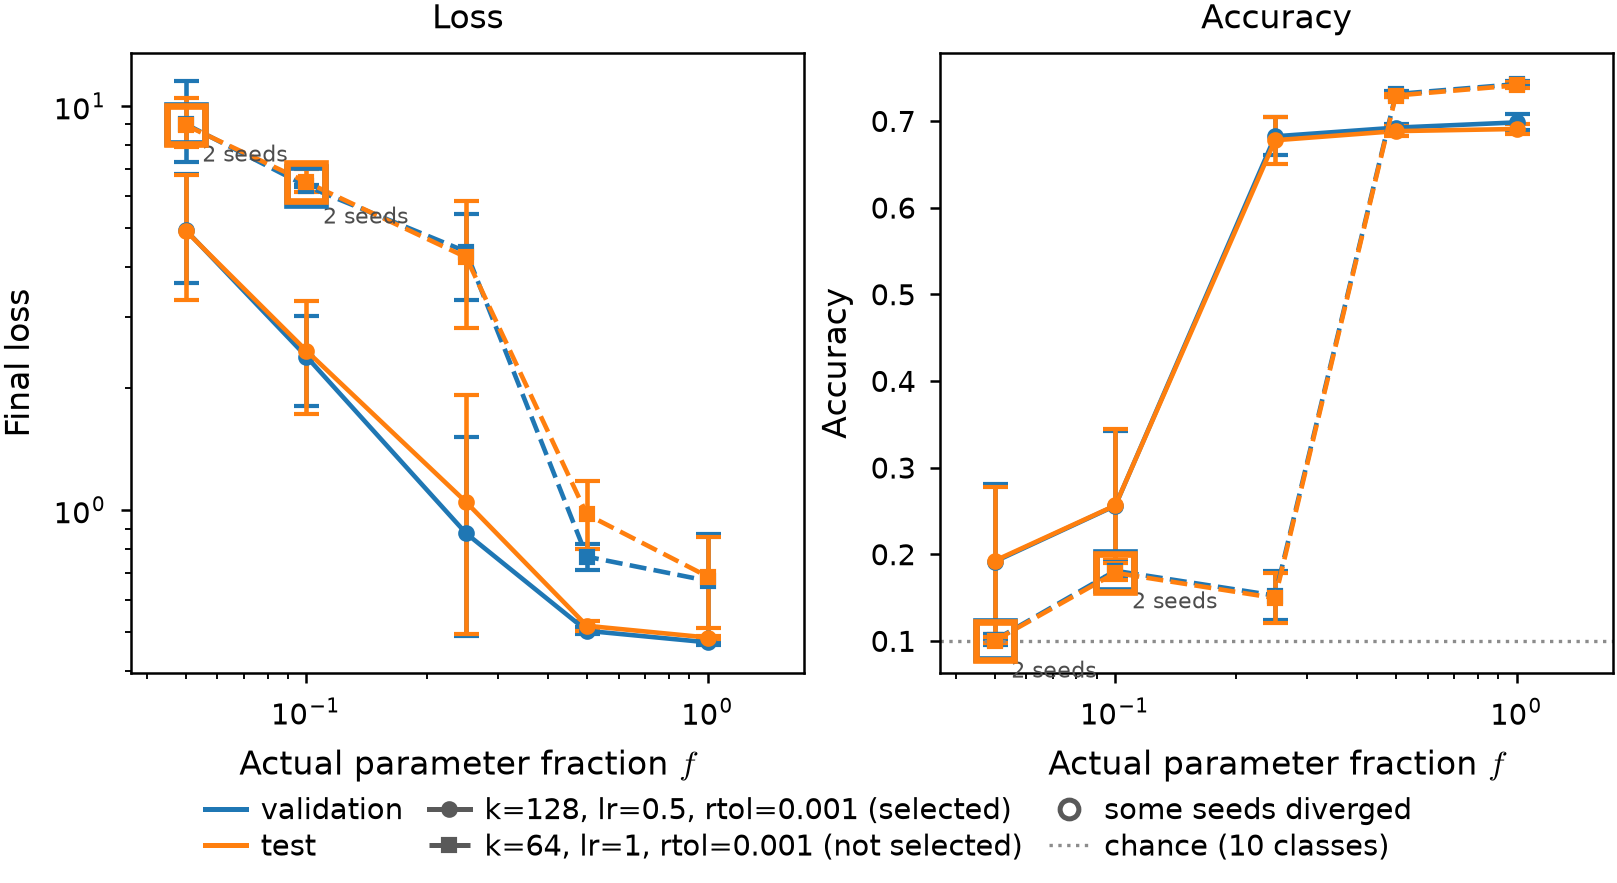

fig5_quality: 5.39 x 2.95 in on the page (shown at 2x)


In [16]:
f = pf.make('fig5_quality')
f.show(zoom=2)

In [17]:
# --- edit fig5_quality -------------------------------------------------------
# its own knobs: aspect, chance_line, extra_h, fraction, legend_fontsize, legend_loc, legend_marker_size, legend_ncol, note_fontsize, seed_note, style_fraction, styles, title_fontsize, xlim_pad_hi, xlim_pad_lo
# f = pf.make('fig5_quality', aspect=0.9, chance_line=True, extra_h=0.52)
# f = pf.make('fig5_quality', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('fig5_quality', aspect=0.95)              # ... and make the CLI agree

## `gpt2`

F11: GPT-2 small, validation loss vs optimisation step -- the best lr per method, and all of Sven's lrs on the ``cmap`` ramp.  One seed, no band.

Its own knobs:

* `aspect` — default `0.9`
* `cmap` — default `'viridis'`
* `cmap_lo` — default `0.08`
* `cmap_span` — default `0.82`
* `extra_h` — default `0.3`
* `fraction` — default `0.49`
* `legend_fontsize` — default `5.4`
* `legend_ncol` — default `1`
* `lr_lw` — default `1.1`
* `lw` — default `0.9`
* `lw_sven` — default `1.4`
* `style_fraction` — default `None`
* `title_fontsize` — default `None`


Loaded 29 runs from ../experiment_results/_cache/exp_gpt2_small_comparison.slim.pkl (slim cache)


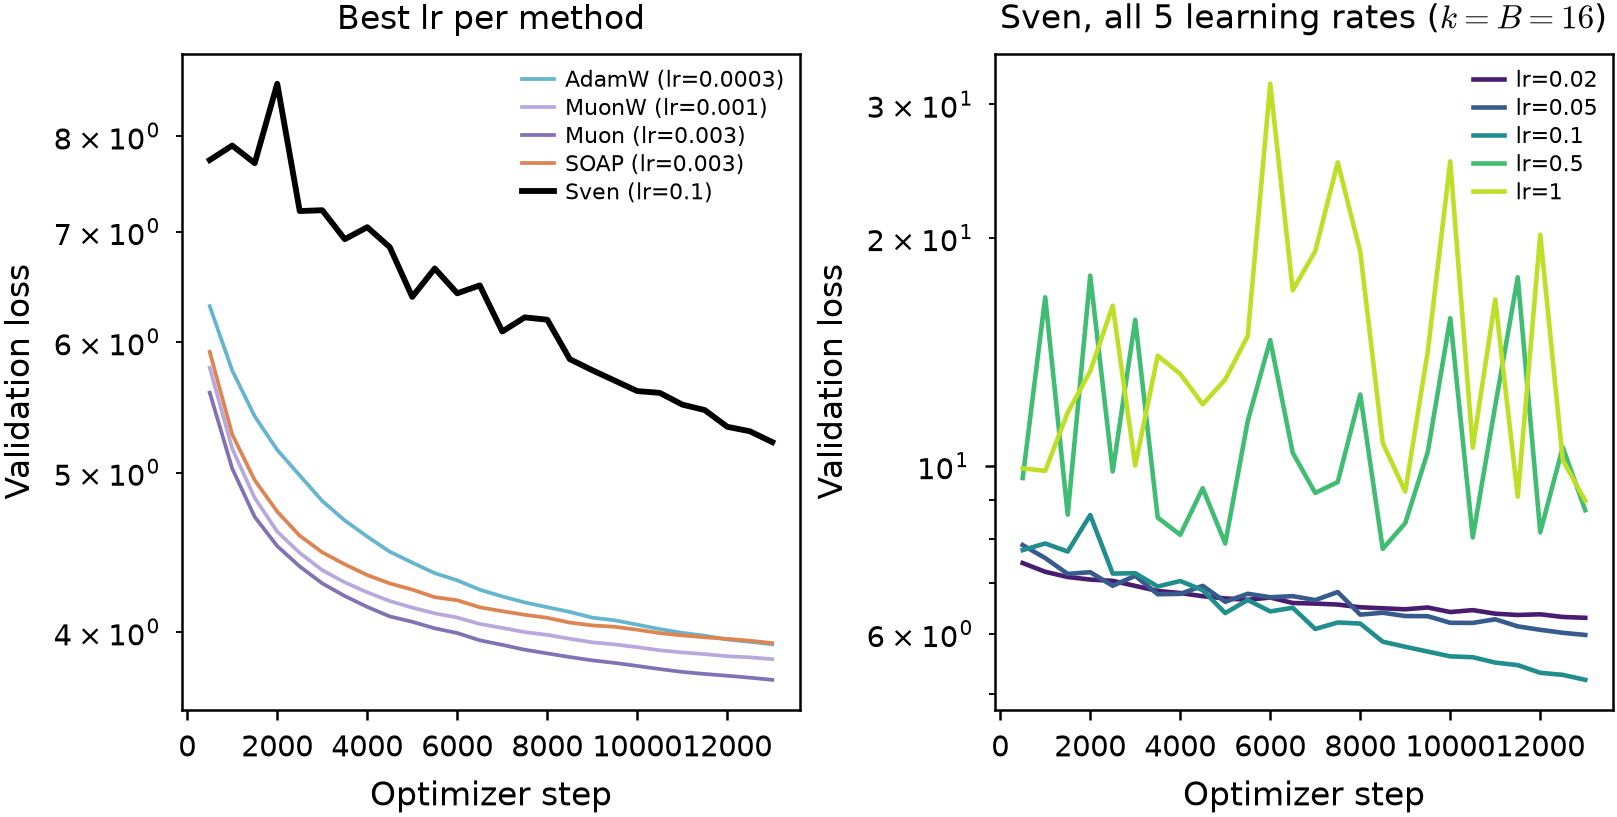

gpt2: 5.39 x 2.73 in on the page (shown at 2x)


In [18]:
f = pf.make('gpt2')
f.show(zoom=2)

In [19]:
# --- edit gpt2 -------------------------------------------------------
# its own knobs: aspect, cmap, cmap_lo, cmap_span, extra_h, fraction, legend_fontsize, legend_ncol, lr_lw, lw, lw_sven, style_fraction, title_fontsize
# f = pf.make('gpt2', aspect=0.9, cmap='viridis', cmap_lo=0.08)
# f = pf.make('gpt2', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('gpt2', aspect=0.95)              # ... and make the CLI agree

## `gpt2_lr`

F11: GPT-2 final loss against the learning rate, one line per method; ``panels`` is [column, axis label] per panel.

Its own knobs:

* `aspect` — default `0.9`
* `extra_h` — default `0.26`
* `fraction` — default `0.49`
* `legend_fontsize` — default `None`
* `legend_loc` — default `'outside lower center'`
* `legend_ncol` — default `5`
* `lw` — default `0.9`
* `lw_sven` — default `1.4`
* `marker_size` — default `2.6`
* `panels` — default `[['val', 'Validation loss'], ['test', 'Test loss']]`
* `style_fraction` — default `None`


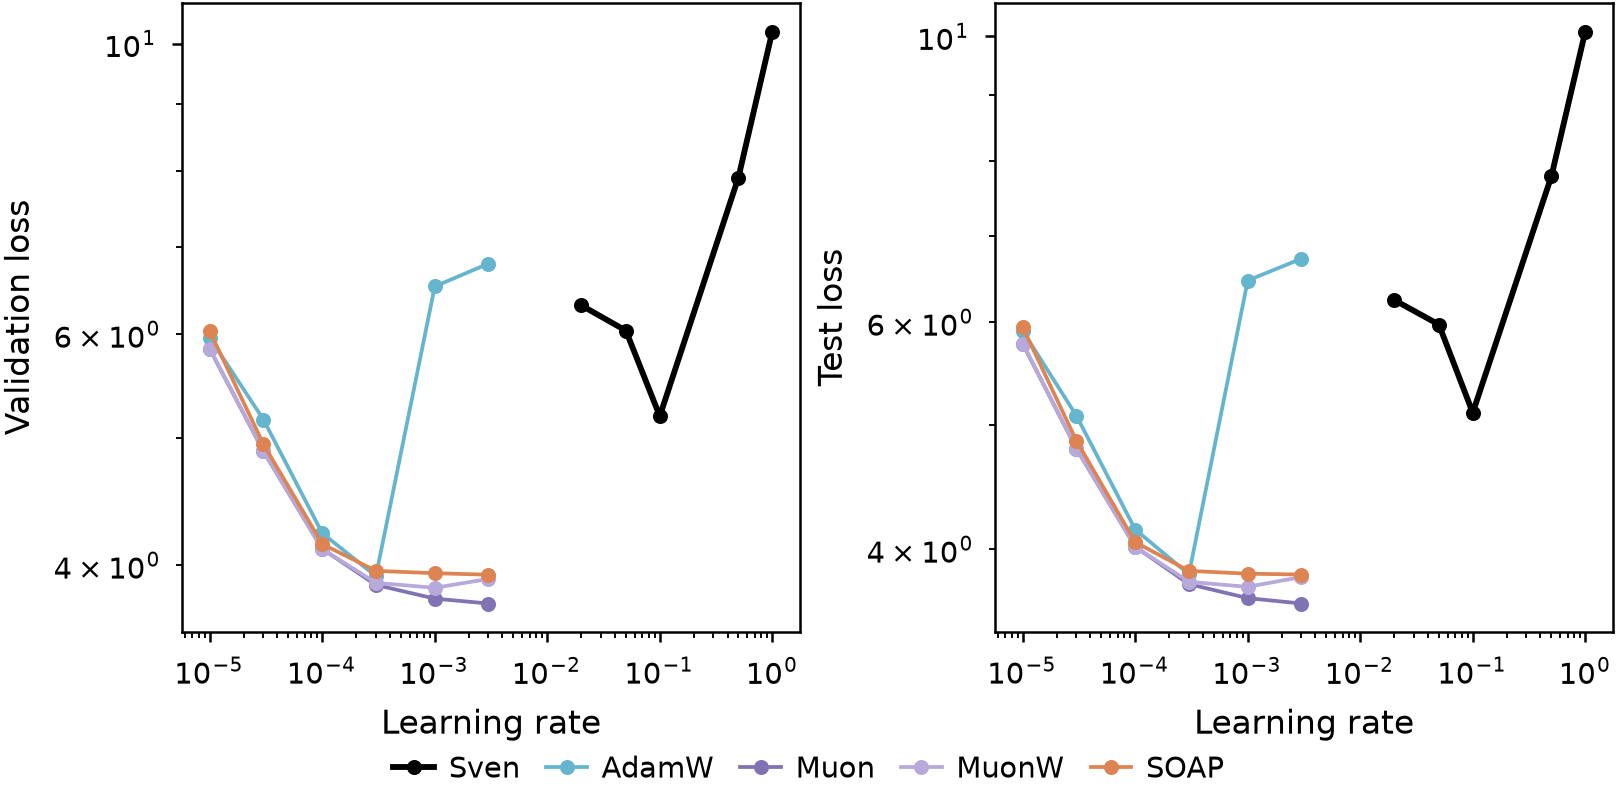

gpt2_lr: 5.39 x 2.69 in on the page (shown at 2x)


In [20]:
f = pf.make('gpt2_lr')
f.show(zoom=2)

In [21]:
# --- edit gpt2_lr -------------------------------------------------------
# its own knobs: aspect, extra_h, fraction, legend_fontsize, legend_loc, legend_ncol, lw, lw_sven, marker_size, panels, style_fraction
# f = pf.make('gpt2_lr', aspect=0.9, extra_h=0.26, fraction=0.49)
# f = pf.make('gpt2_lr', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('gpt2_lr', aspect=0.95)              # ... and make the CLI agree

## `nanogpt`

F11b: nanoGPT vs epoch, vs standalone wall time and vs the learning rate, with the selection of record ringed (``mark_selected``).

Its own knobs:

* `aspect` — default `0.95`
* `band` — default `True`
* `extra_h` — default `0.42`
* `fraction` — default `0.32`
* `headroom` — default `0.04`
* `legend_band` — default `True`
* `legend_fontsize` — default `None`
* `legend_loc` — default `'outside lower center'`
* `legend_ncol` — default `4`
* `lw` — default `0.9`
* `lw_sven` — default `1.4`
* `lw_time` — default `0.85`
* `mark_selected` — default `True`
* `methods` — default `None`
* `ring_size` — default `44`
* `style_fraction` — default `None`
* `title_fontsize` — default `None`


Loaded 140 runs from ../experiment_results/_cache/exp_nanogpt_speedrun.slim.pkl (slim cache)


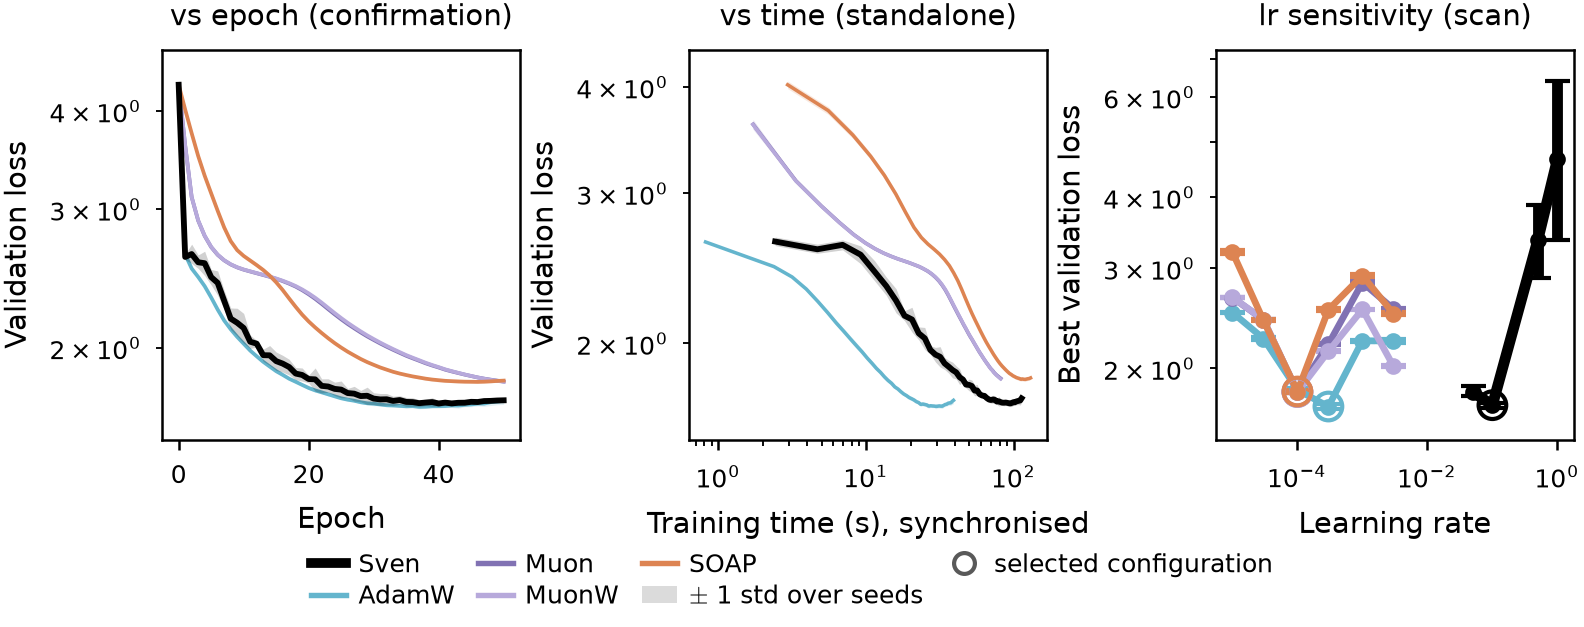

nanogpt: 5.28 x 2.09 in on the page (shown at 2x)


In [22]:
f = pf.make('nanogpt')
f.show(zoom=2)

In [23]:
# --- edit nanogpt -------------------------------------------------------
# its own knobs: aspect, band, extra_h, fraction, headroom, legend_band, legend_fontsize, legend_loc, legend_ncol, lw, lw_sven, lw_time, mark_selected, methods, ring_size, style_fraction, title_fontsize
# f = pf.make('nanogpt', aspect=0.95, band=True, extra_h=0.42)
# f = pf.make('nanogpt', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('nanogpt', aspect=0.95)              # ... and make the CLI agree

## `profile_batchsize`

F15: step time (top) and peak memory (bottom) against the batch size B; ``fraction`` None spreads the columns over the full line width.

Its own knobs:

* `analytic` — default `True`
* `archs` — default `['toy_1d', 'mnist', 'nanogpt', 'cifar_resnet18']`
* `aspect` — default `0.95`
* `extra_h` — default `0.46`
* `fraction` — default `None`
* `headroom` — default `0.06`
* `legend_fontsize` — default `None`
* `legend_loc` — default `'outside lower center'`
* `legend_ncol` — default `5`
* `methods` — default `['gram_hooks', 'gram_full', 'gram_chunked', 'classic', 'Adam', 'SGD']`
* `style_fraction` — default `0.49`
* `title_fontsize` — default `6.4`
* `ytick_fontsize` — default `5.8`


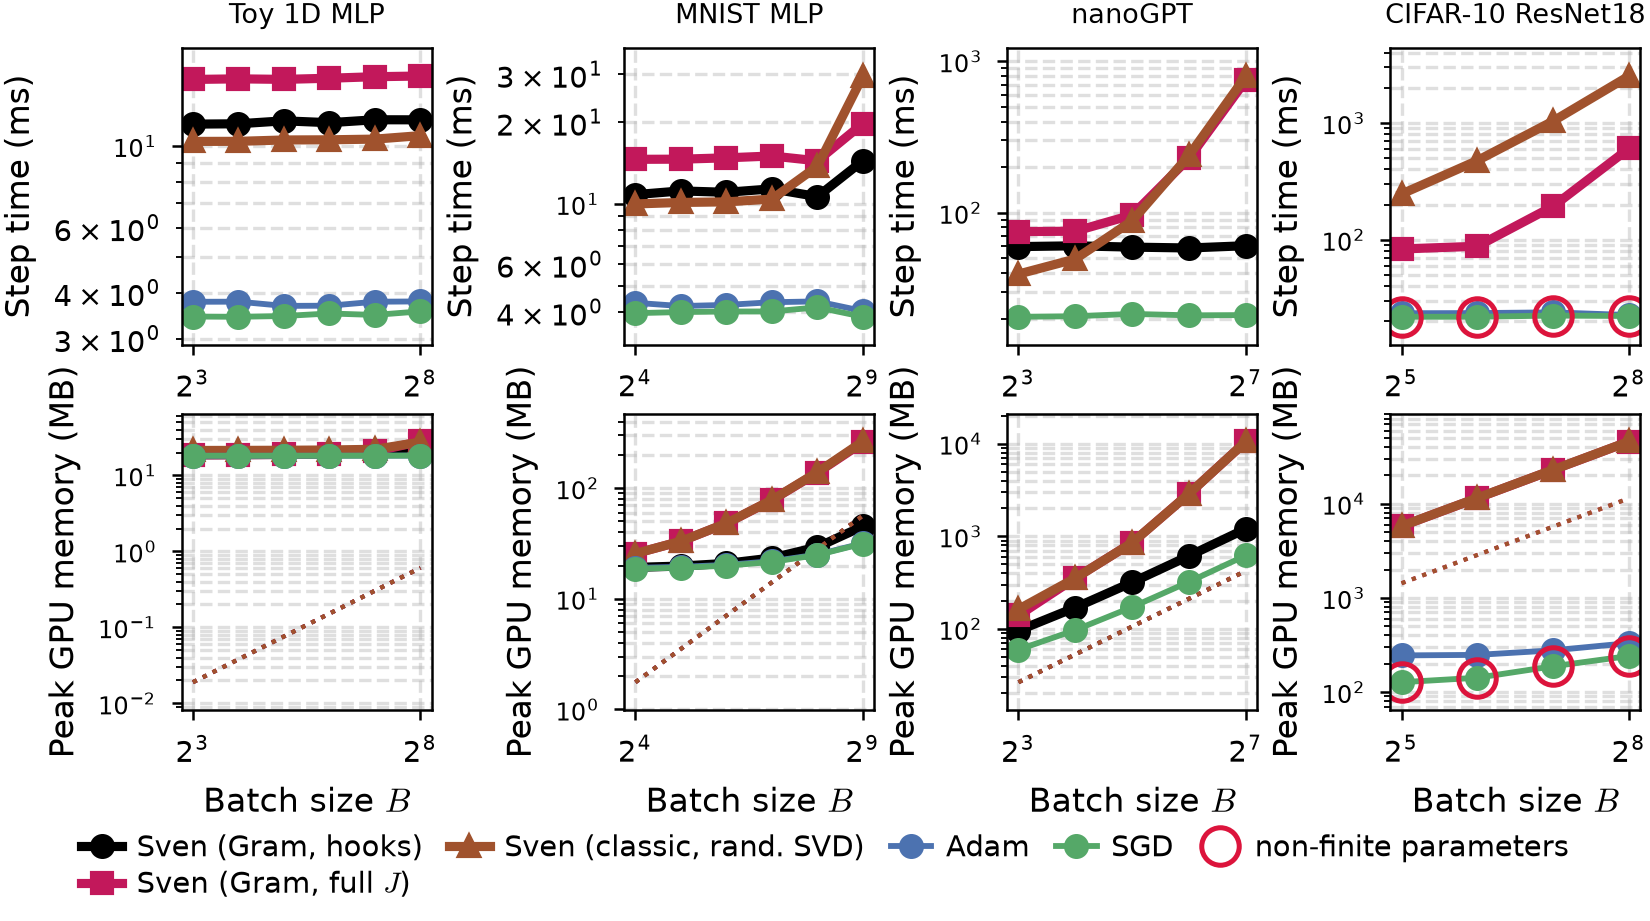

profile_batchsize: 5.50 x 3.07 in on the page (shown at 2x)


In [24]:
f = pf.make('profile_batchsize')
f.show(zoom=2)

In [25]:
# --- edit profile_batchsize -------------------------------------------------------
# its own knobs: analytic, archs, aspect, extra_h, fraction, headroom, legend_fontsize, legend_loc, legend_ncol, methods, style_fraction, title_fontsize, ytick_fontsize
# f = pf.make('profile_batchsize', analytic=True, archs=['toy_1d', 'mnist', 'nanogpt', 'cifar_resnet18'], aspect=0.95)
# f = pf.make('profile_batchsize', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('profile_batchsize', aspect=0.95)              # ... and make the CLI agree

## `profile_k_sweep`

F15: step time against the rank cap k, one panel per architecture that has a k sweep (``ncols`` None = 2 panels wide up to four architectures).

Its own knobs:

* `archs` — default `None`
* `aspect` — default `0.82`
* `extra_h` — default `0.34`
* `fraction` — default `0.49`
* `headroom` — default `0.06`
* `legend_fontsize` — default `None`
* `legend_loc` — default `'outside lower center'`
* `legend_ncol` — default `4`
* `methods` — default `['gram_hooks', 'gram_full', 'gram_chunked', 'classic']`
* `ncols` — default `None`
* `style_fraction` — default `None`
* `title_fontsize` — default `None`


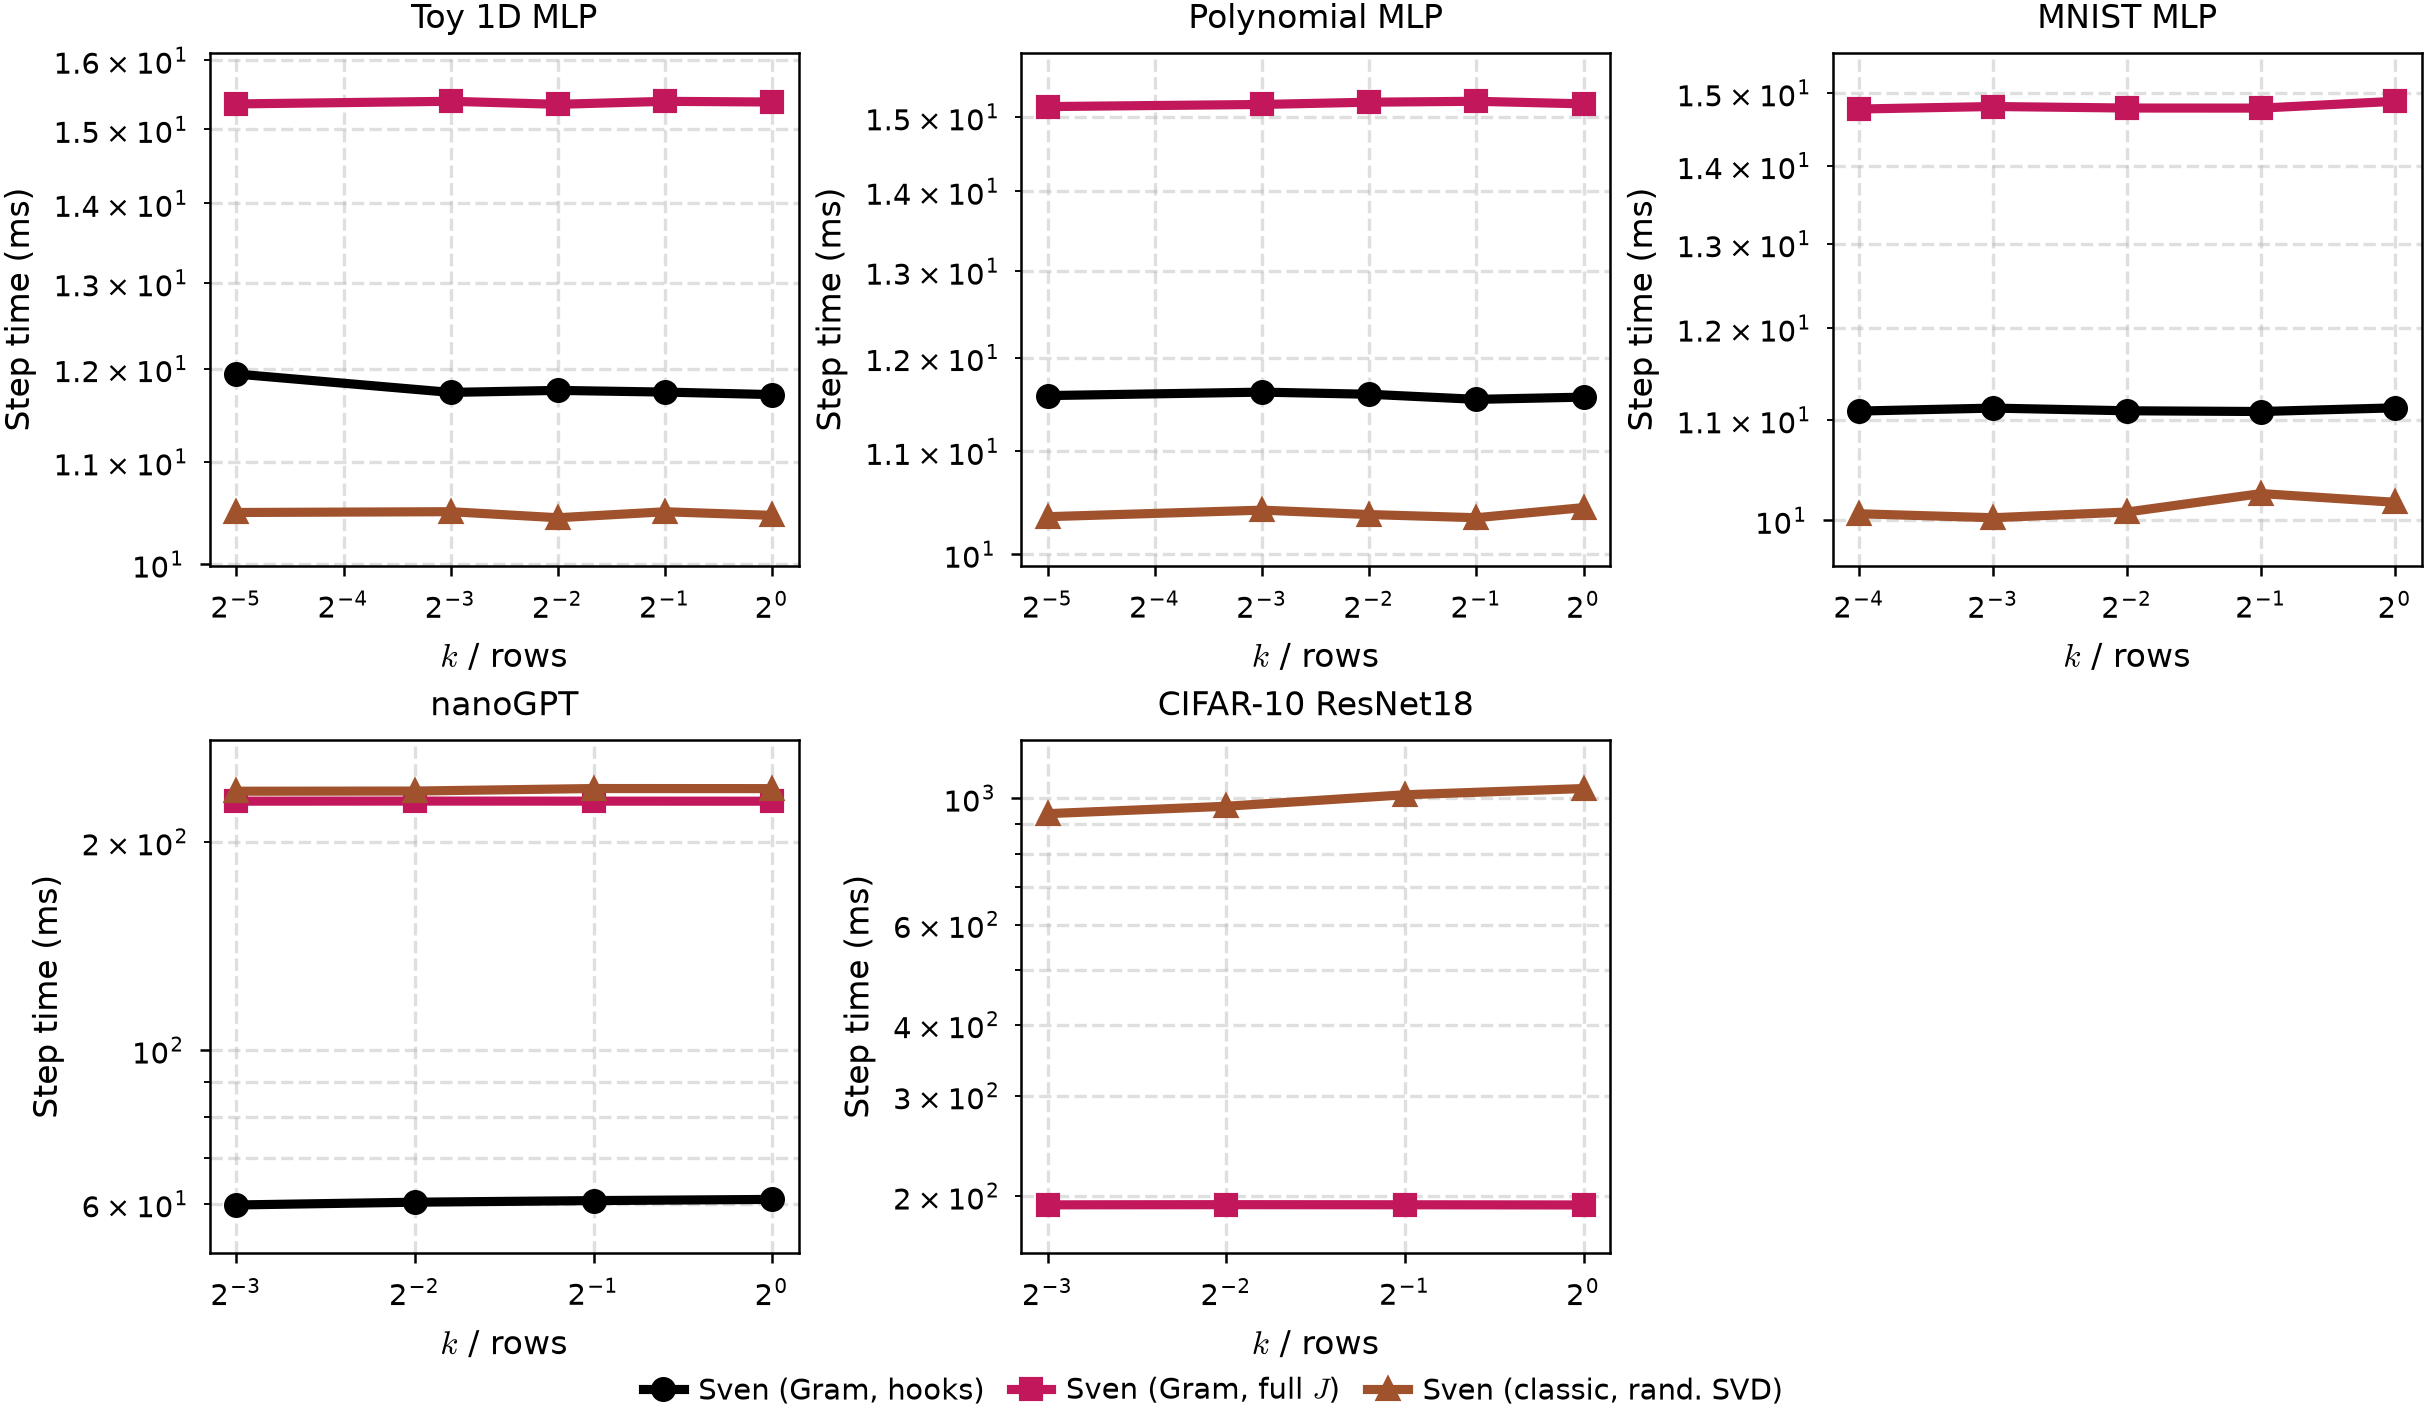

profile_k_sweep: 8.08 x 4.76 in on the page (shown at 2x)


In [26]:
f = pf.make('profile_k_sweep')
f.show(zoom=2)

In [27]:
# --- edit profile_k_sweep -------------------------------------------------------
# its own knobs: archs, aspect, extra_h, fraction, headroom, legend_fontsize, legend_loc, legend_ncol, methods, ncols, style_fraction, title_fontsize
# f = pf.make('profile_k_sweep', archs=None, aspect=0.82, extra_h=0.34)
# f = pf.make('profile_k_sweep', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('profile_k_sweep', aspect=0.95)              # ... and make the CLI agree

## `profile_methods`

F15: step time relative to Adam and peak memory relative to SGD, methods x architectures, as a heat map; ``panels`` is [column, title] per panel.

Its own knobs:

* `archs` — default `None`
* `aspect` — default `0.82`
* `fmt` — default `'{:.3g}'`
* `fraction` — default `1.0`
* `panels` — default `[['rel_time', 'Step time / Adam'], ['rel_mem', 'Peak memory / SGD']]`
* `share_method_labels` — default `True`
* `style_fraction` — default `None`
* `tick_fontsize` — default `6.5`
* `title_fontsize` — default `None`
* `wspace` — default `0.04`


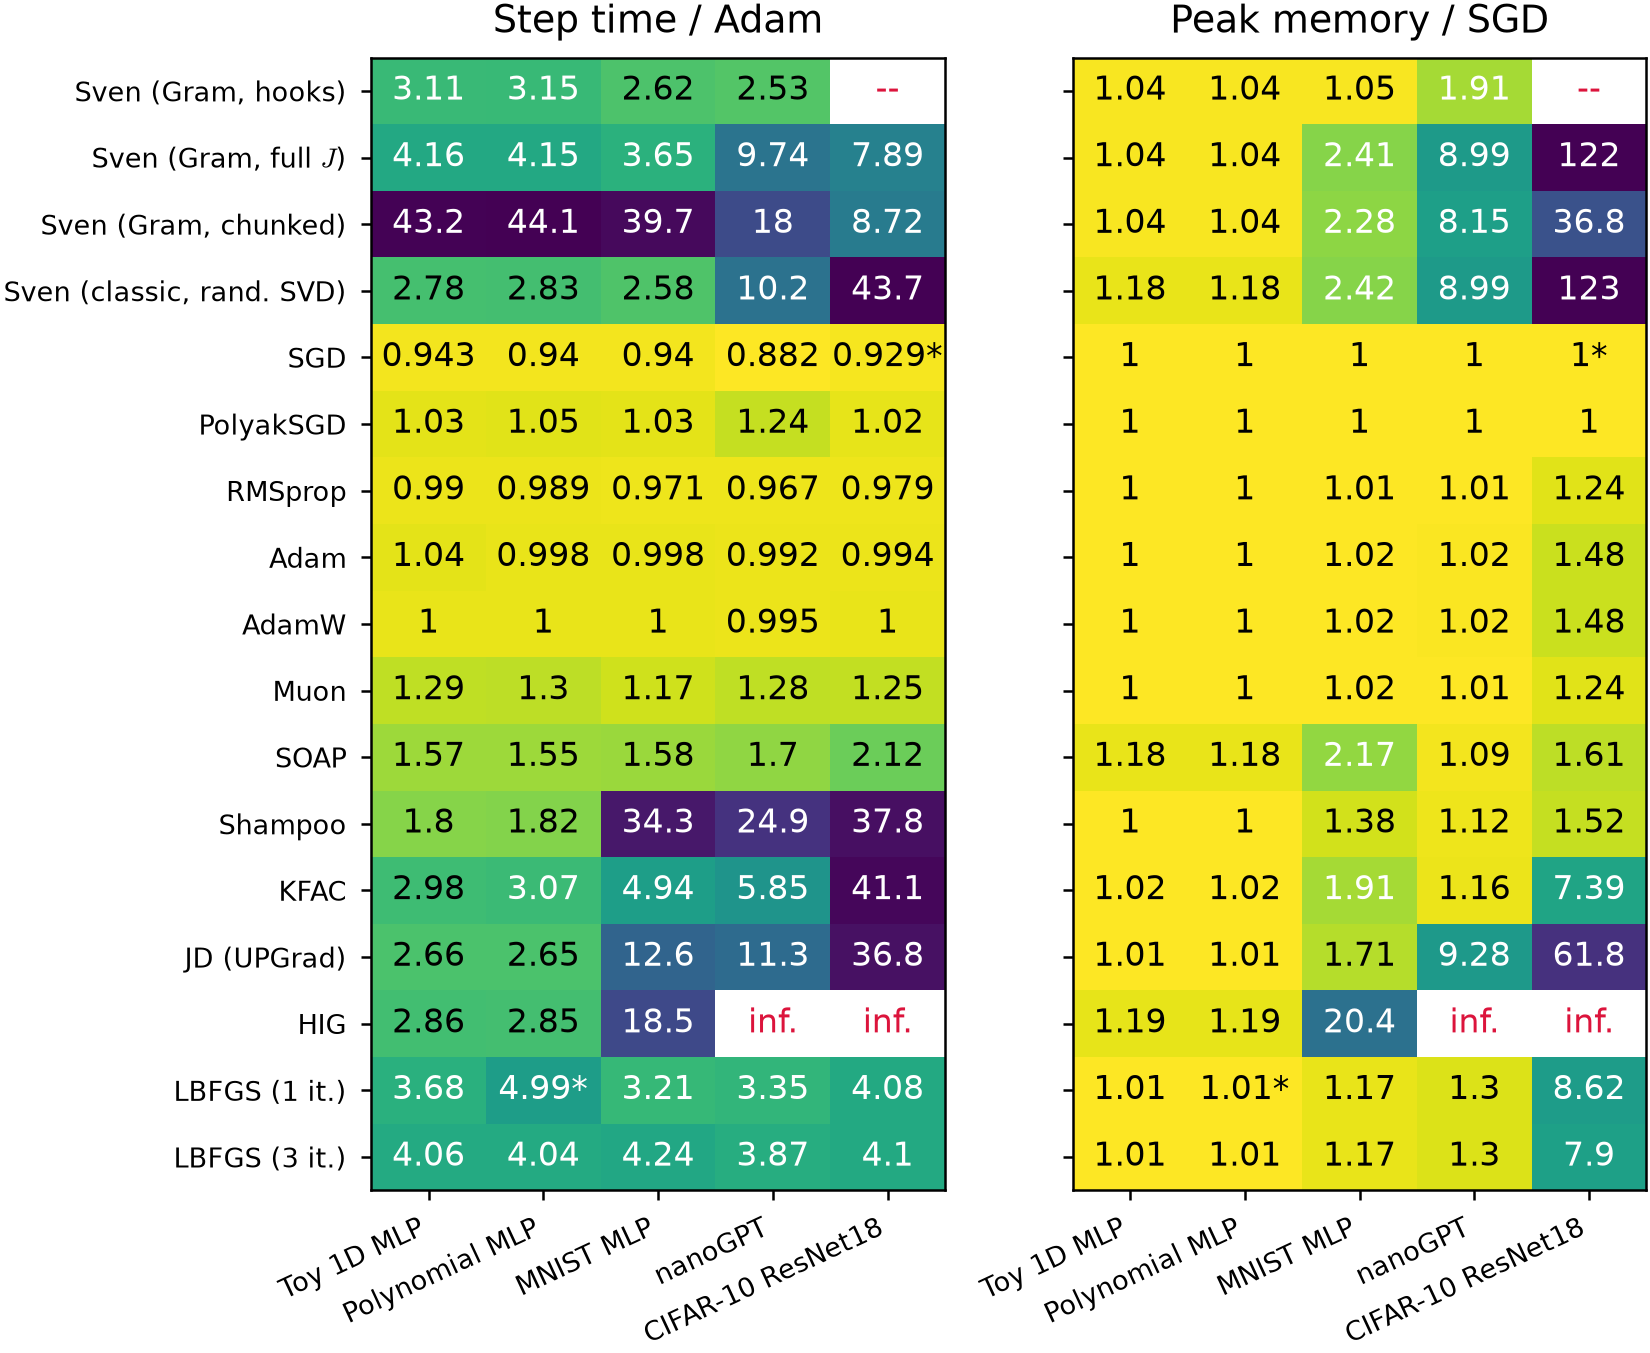

profile_methods: 5.50 x 4.51 in on the page (shown at 2x)


In [28]:
f = pf.make('profile_methods')
f.show(zoom=2)

In [29]:
# --- edit profile_methods -------------------------------------------------------
# its own knobs: archs, aspect, fmt, fraction, panels, share_method_labels, style_fraction, tick_fontsize, title_fontsize, wspace
# f = pf.make('profile_methods', archs=None, aspect=0.82, fmt='{:.3g}')
# f = pf.make('profile_methods', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('profile_methods', aspect=0.95)              # ... and make the CLI agree

## `profile_pareto`

F15: the chunked capture's memory / time front against the other backends; ``archs`` is the preference order and ``max_panels`` how many fit.

Its own knobs:

* `annotate_ends` — default `True`
* `archs` — default `['cifar_resnet18', 'nanogpt', 'mnist', 'toy_1d']`
* `aspect` — default `0.95`
* `extra_h` — default `0.4`
* `fraction` — default `0.49`
* `front_grid` — default `True`
* `legend_fontsize` — default `None`
* `legend_loc` — default `'outside lower center'`
* `legend_ncol` — default `4`
* `max_panels` — default `2`
* `style_fraction` — default `None`
* `title_fontsize` — default `None`


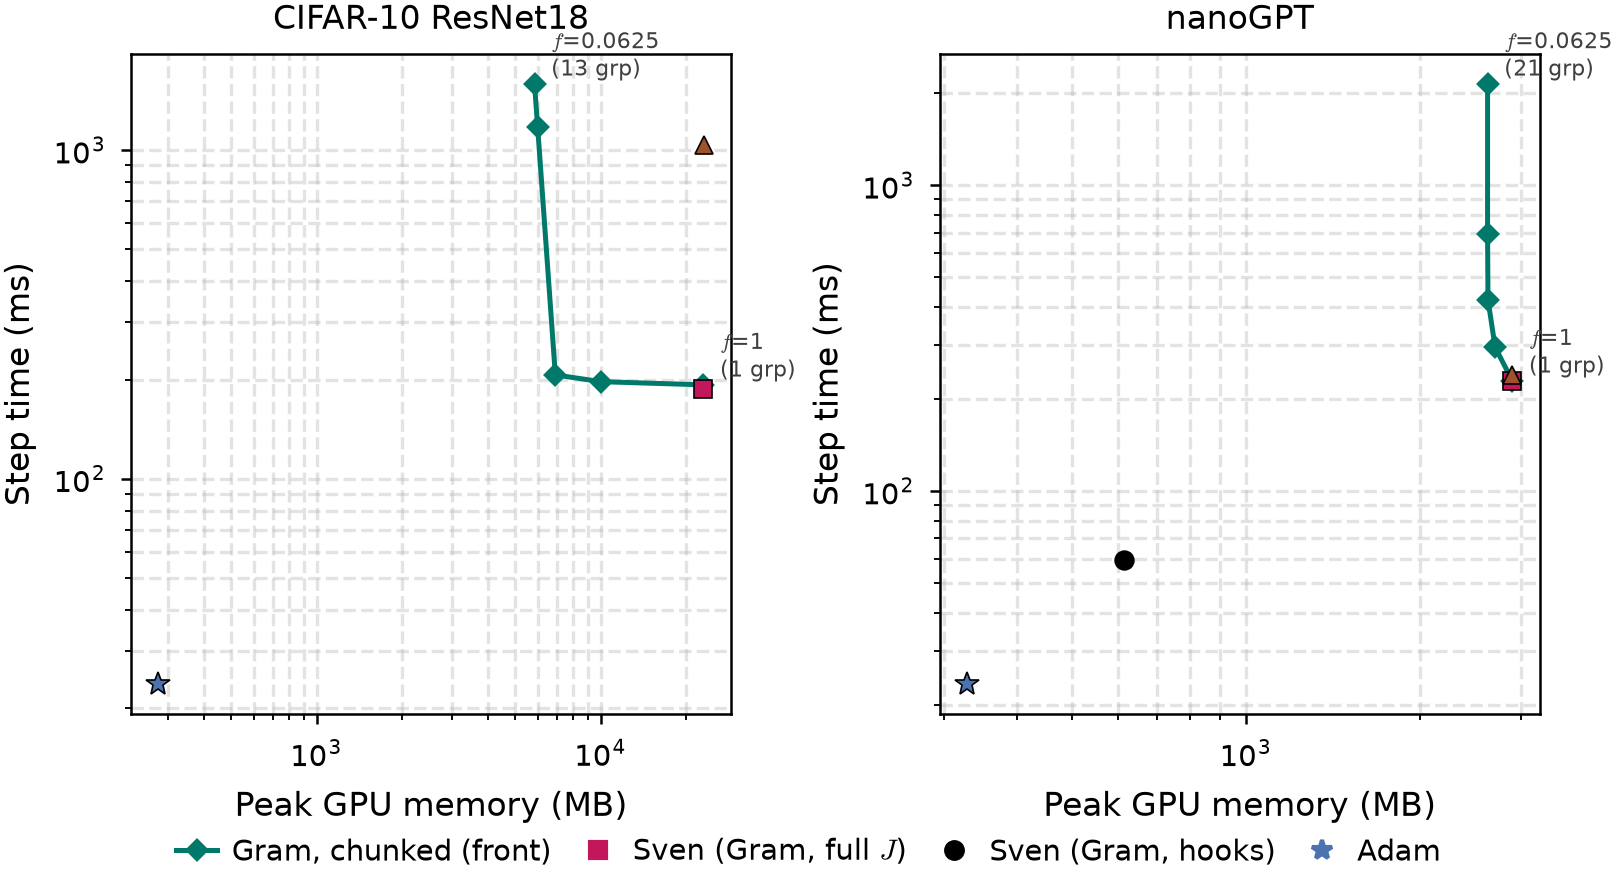

profile_pareto: 5.39 x 2.96 in on the page (shown at 2x)


In [30]:
f = pf.make('profile_pareto')
f.show(zoom=2)

In [31]:
# --- edit profile_pareto -------------------------------------------------------
# its own knobs: annotate_ends, archs, aspect, extra_h, fraction, front_grid, legend_fontsize, legend_loc, legend_ncol, max_panels, style_fraction, title_fontsize
# f = pf.make('profile_pareto', annotate_ends=True, archs=['cifar_resnet18', 'nanogpt', 'mnist', 'toy_1d'], aspect=0.95)
# f = pf.make('profile_pareto', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('profile_pareto', aspect=0.95)              # ... and make the CLI agree

## `profile_phases`

F15: capture against solve+apply per Sven backend and architecture, with the architecture names above their bar groups (``arch_labels``).

Its own knobs:

* `arch_label_fontsize` — default `6.4`
* `arch_labels` — default `True`
* `archs` — default `None`
* `aspect` — default `0.46`
* `fraction` — default `1.0`
* `group_gap` — default `0.8`
* `legend_fontsize` — default `6.5`
* `legend_loc` — default `'upper left'`
* `legend_ncol` — default `2`
* `style_fraction` — default `None`
* `title_fontsize` — default `None`
* `xtick_fontsize` — default `5.6`


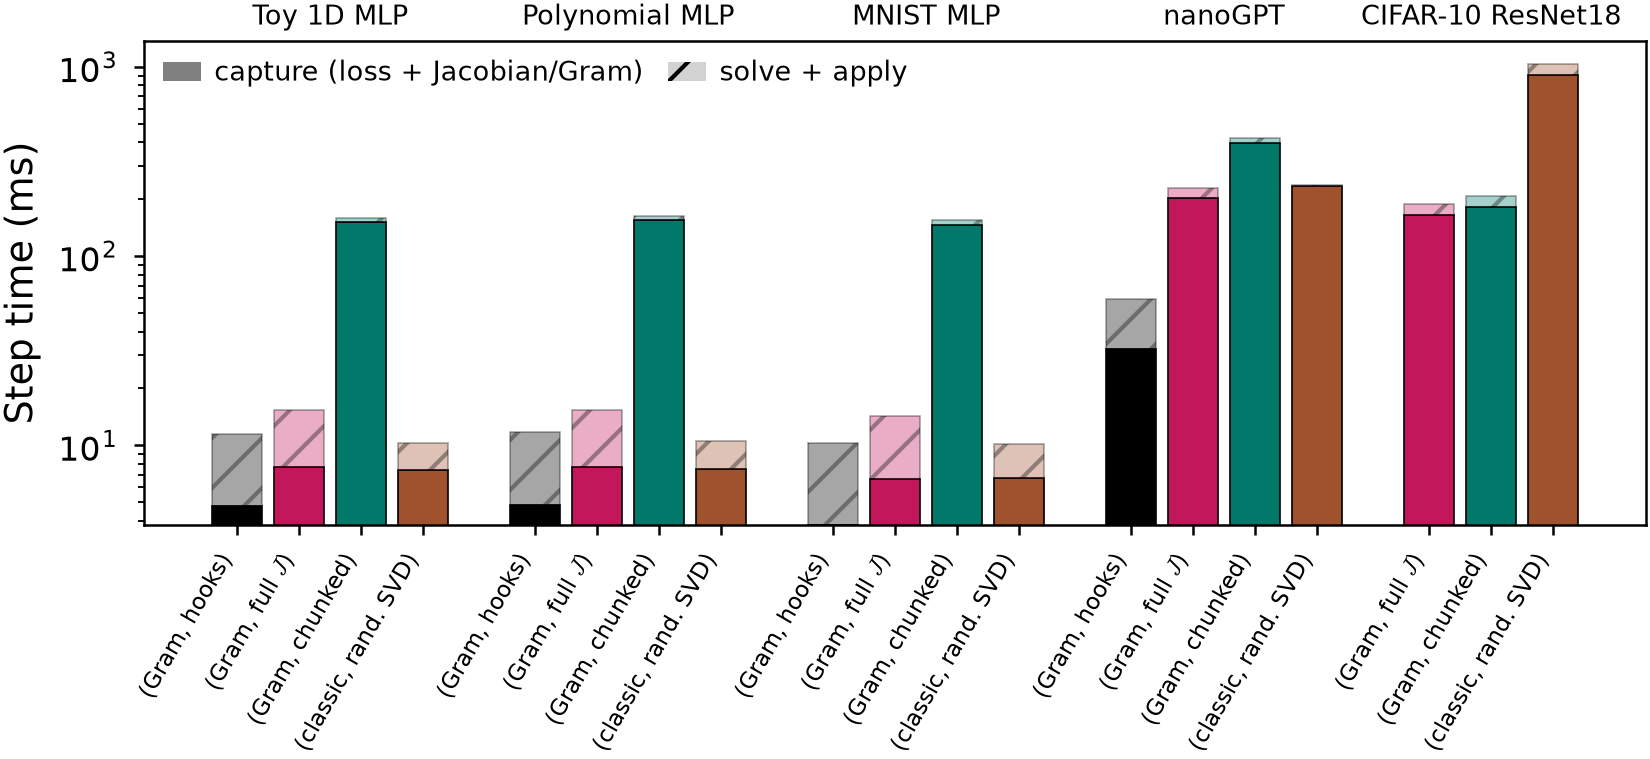

profile_phases: 5.50 x 2.53 in on the page (shown at 2x)


In [32]:
f = pf.make('profile_phases')
f.show(zoom=2)

In [33]:
# --- edit profile_phases -------------------------------------------------------
# its own knobs: arch_label_fontsize, arch_labels, archs, aspect, fraction, group_gap, legend_fontsize, legend_loc, legend_ncol, style_fraction, title_fontsize, xtick_fontsize
# f = pf.make('profile_phases', arch_label_fontsize=6.4, arch_labels=True, archs=None)
# f = pf.make('profile_phases', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('profile_phases', aspect=0.95)              # ... and make the CLI agree

## `profile_scaling`

F15: step time and peak memory against the parameter count over the width sweeps (skipped when the profile root has none).

Its own knobs:

* `analytic` — default `True`
* `archs` — default `None`
* `aspect` — default `0.82`
* `extra_h` — default `0.4`
* `fraction` — default `0.49`
* `headroom` — default `0.06`
* `legend_fontsize` — default `None`
* `legend_loc` — default `'outside lower center'`
* `legend_ncol` — default `5`
* `methods` — default `['gram_hooks', 'gram_full', 'gram_chunked', 'classic', 'Adam', 'SGD']`
* `style_fraction` — default `None`
* `title_fontsize` — default `None`


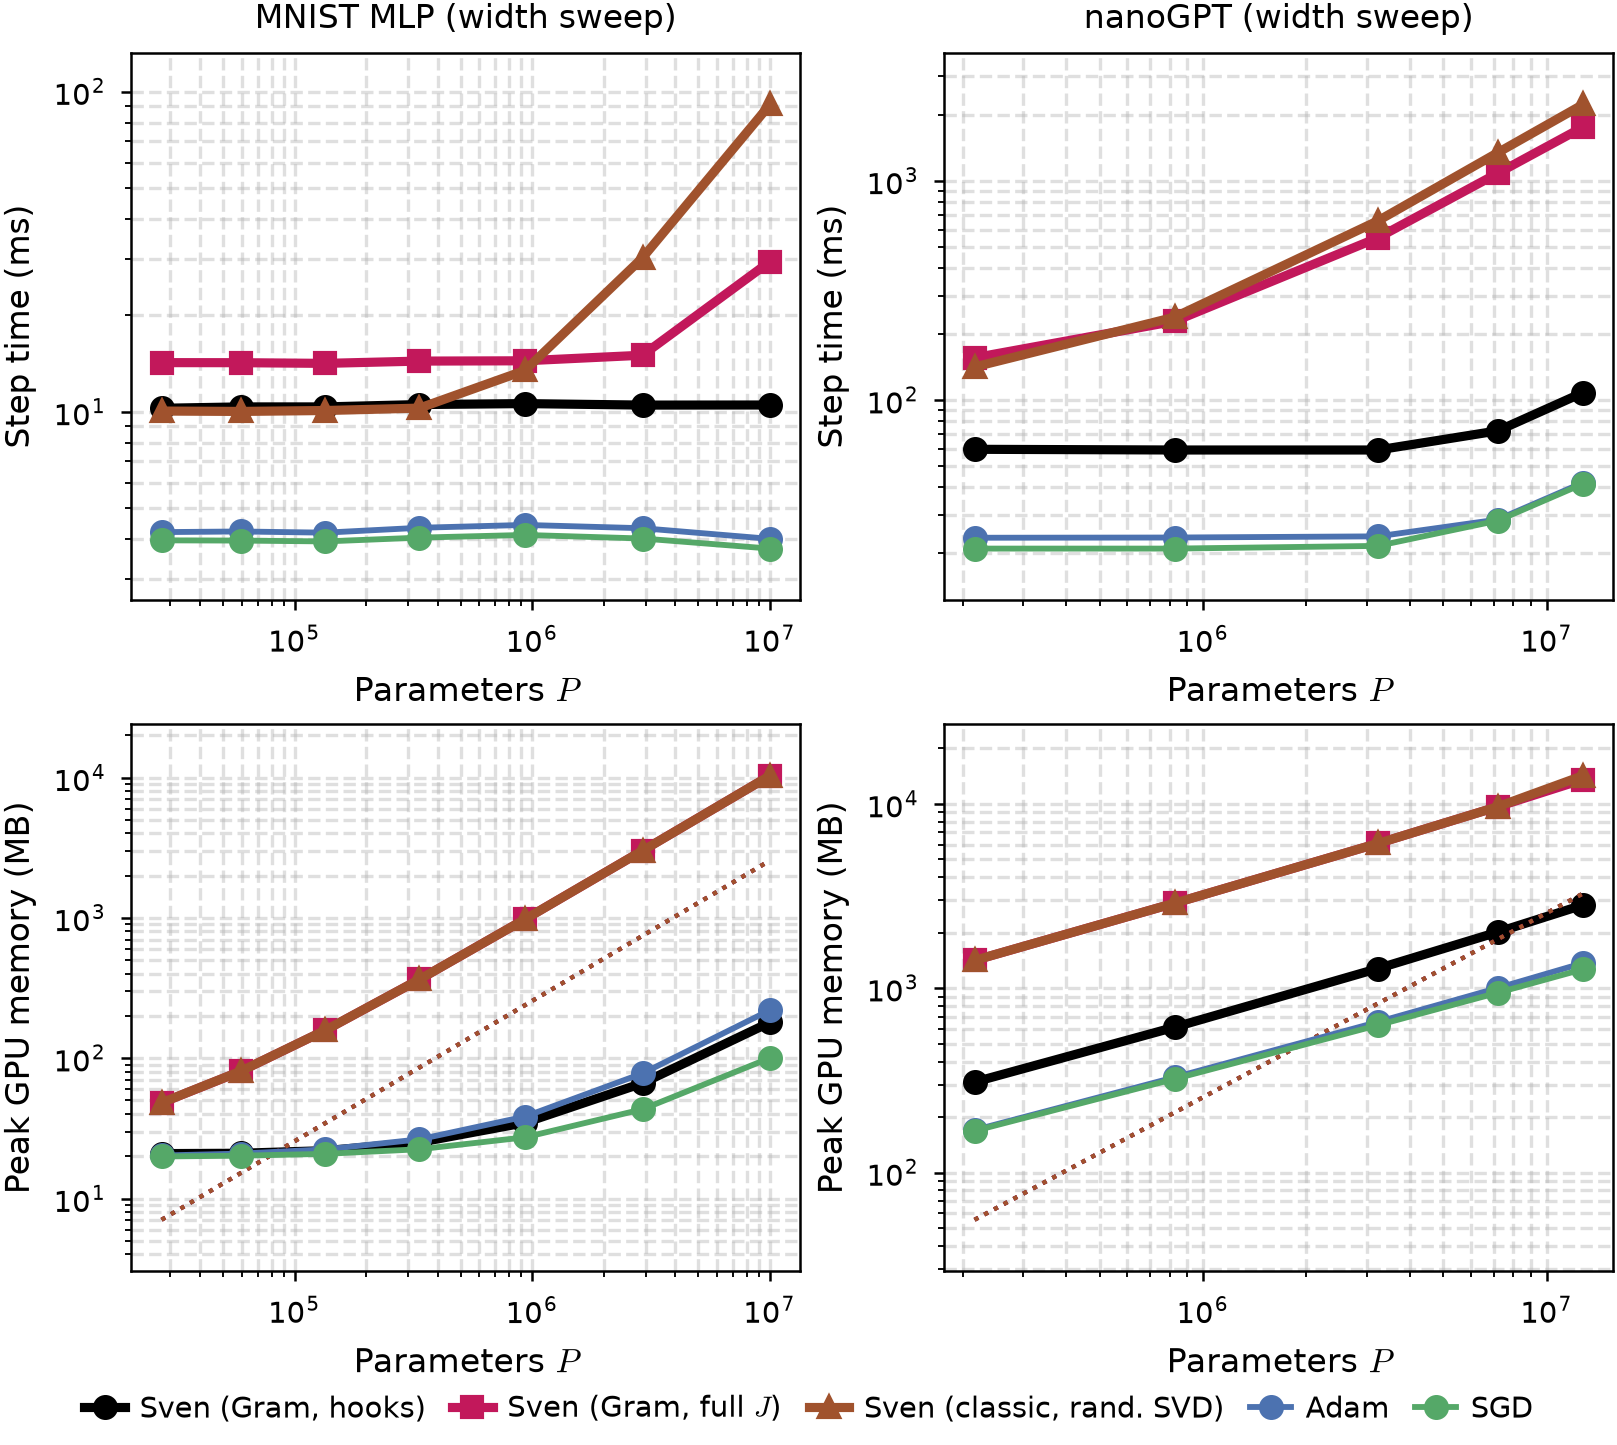

profile_scaling: 5.39 x 4.82 in on the page (shown at 2x)


In [34]:
f = pf.make('profile_scaling')
f.show(zoom=2)

In [35]:
# --- edit profile_scaling -------------------------------------------------------
# its own knobs: analytic, archs, aspect, extra_h, fraction, headroom, legend_fontsize, legend_loc, legend_ncol, methods, style_fraction, title_fontsize
# f = pf.make('profile_scaling', analytic=True, archs=None, aspect=0.82)
# f = pf.make('profile_scaling', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('profile_scaling', aspect=0.95)              # ... and make the CLI agree

## What is pinned

Everything this notebook has pinned, i.e. what `python -m paper_assets` will replay. `pf.unpin(<name>)` drops one, `pf.unpin()` drops them all.

In [36]:
pf.pinned()

{}